# Elo Merchant Category Recommendation

## От знакомства с данными до финального прогноза

Нужно предсказать значение `target` для каждой карты из `test.csv`.

В исходных данных разные уровни детализации:

- в `train.csv` и `test.csv` одна строка соответствует одной карте;
- в `historical_transactions.csv` и `new_merchant_transactions.csv` хранятся отдельные покупки;
- в `merchants.csv` находятся характеристики продавцов;
- итоговый прогноз снова нужен на уровне `card_id`.

Я иду от простого решения к более сложному:

1. проверяю файлы и распределение target;
2. изучаю покупки и продавцов;
3. формулирую признаки по результатам EDA;
4. агрегирую транзакции до уровня карты;
5. сравниваю группы признаков;
6. обучаю baseline и настраиваю LightGBM, XGBoost и CatBoost;
7. проверяю target encoding и отдельную модель экстремального сегмента;
8. сравниваю одиночные модели и ансамбли;
9. выбираю финальный прогноз по OOF-результатам;
10. создаю `submission.csv`.


## 0. Запуск

Ожидаемая структура папки:

```text
project/
├── elo_final_research_gpu.ipynb
├── data/
│   ├── train.csv
│   ├── test.csv
│   ├── historical_transactions.csv
│   ├── new_merchant_transactions.csv
│   ├── merchants.csv
│   └── sample_submission.csv
├── submissions/
└── reports/
```

## 1. Подготовка окружения

In [1]:
from pathlib import Path
import gc
import os
import subprocess
import platform
import sys
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

import sklearn
from sklearn.metrics import (
    average_precision_score,
    confusion_matrix,
    mean_squared_error,
    roc_auc_score,
)
from sklearn.model_selection import KFold, StratifiedKFold

try:
    from sklearn.metrics import root_mean_squared_error
except ImportError:
    def root_mean_squared_error(y_true, y_pred):
        return mean_squared_error(y_true, y_pred, squared=False)

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", message=".*IProgress not found.*")

pd.set_option("display.max_columns", 160)
pd.set_option("display.max_rows", 120)
sns.set_theme(style="whitegrid")

Сначала нахожу папку с данными и создаю каталоги только для итогового
`submission.csv` и скриншота результата. Промежуточные таблицы и модели
на диск не сохраняются: при новом запуске расчёт начинается заново.

In [2]:
PROJECT_DIR = Path.cwd().resolve()
DATA_DIR = PROJECT_DIR / "data" / "raw"
SUBMISSIONS_DIR = PROJECT_DIR / "submissions"
REPORTS_DIR = PROJECT_DIR / "reports"

for directory in [SUBMISSIONS_DIR, REPORTS_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

if not (DATA_DIR / "train.csv").exists():
    raise FileNotFoundError(
        "Не найден train.csv. Запустите ноутбук из папки проекта и "
        "разместите файлы соревнования в data/raw/."
    )

print("Папка проекта:", PROJECT_DIR)
print("Папка с данными:", DATA_DIR)

Папка проекта: /home/vmuser/Загрузки/03_kaggle_feature_ensemble (1)/03_kaggle_feature_ensemble
Папка с данными: /home/vmuser/Загрузки/03_kaggle_feature_ensemble (1)/03_kaggle_feature_ensemble/data


Ниже находятся настройки полного запуска. Подбор параметров специально оставлен
достаточно большим: LightGBM и XGBoost получают по 60 trial, CatBoost — 40,
классификатор экстремального сегмента — 30.

In [3]:
SEED = 42
N_SPLITS = 5
CHUNK_SIZE = 750_000

GPU_DEVICE_ID = 0
os.environ["CUDA_VISIBLE_DEVICES"] = str(GPU_DEVICE_ID)

LIGHTGBM_GPU_PLATFORM_ID = None

LGB_OPTUNA_TRIALS = 60
XGB_OPTUNA_TRIALS = 60
CAT_OPTUNA_TRIALS = 40
OUTLIER_OPTUNA_TRIALS = 30

BOOTSTRAP_ITERATIONS = 2_000

Вывожу версии библиотек, чтобы результат можно было воспроизвести.


In [4]:
import lightgbm
import xgboost
import catboost
import optuna

versions = pd.Series(
    {
        "python": sys.version.split()[0],
        "numpy": np.__version__,
        "pandas": pd.__version__,
        "scikit-learn": sklearn.__version__,
        "lightgbm": lightgbm.__version__,
        "xgboost": xgboost.__version__,
        "catboost": catboost.__version__,
        "optuna": optuna.__version__,
        "platform": platform.platform(),
    },
    name="version",
)
display(versions.to_frame())

,version
python,3.13.9
numpy,2.4.2
pandas,2.3.3
scikit-learn,1.7.2
lightgbm,4.7.0.99
xgboost,3.4.0
catboost,1.2.10
optuna,4.9.0
platform,Linux-7.0.0-28-generic-x86_64-with-glibc2.39


## 1.1. Проверка GPU

Перед чтением больших файлов запускаю короткий тест трёх библиотек.

- **XGBoost** использует CUDA.
- **CatBoost** использует CUDA на устройстве `0`.
- **LightGBM** использует CUDA-сборку в Linux или OpenCL GPU-сборку в Windows.

Проверка строгая: если какая-либо библиотека не умеет обучаться на GPU,
выполнение останавливается. Так длительный эксперимент не сможет незаметно
запуститься на CPU.

В Windows обычная сборка LightGBM из `pip` может не содержать GPU-поддержку.
Для неё требуется сборка с OpenCL. В Linux предпочтительна CUDA-сборка LightGBM.


In [5]:
from catboost import CatBoostRegressor
from catboost.utils import get_gpu_device_count
from xgboost import XGBRegressor

nvidia_smi = subprocess.run(
    [
        "nvidia-smi",
        "--query-gpu=name,memory.total,driver_version",
        "--format=csv,noheader",
    ],
    capture_output=True,
    text=True,
    check=False,
)

if nvidia_smi.returncode != 0:
    raise RuntimeError(
        "Команда nvidia-smi не выполнилась. Проверьте драйвер NVIDIA "
        "и доступность RTX 5090 в текущем окружении."
    )

print("NVIDIA GPU:")
print(nvidia_smi.stdout.strip())

probe_X = np.random.default_rng(SEED).normal(
    size=(4_096, 24)
).astype("float32")
probe_y = np.random.default_rng(SEED + 1).normal(
    size=4_096
).astype("float32")


xgb_major_version = int(
    xgboost.__version__.split(".")[0]
)

if xgb_major_version >= 2:
    XGBOOST_GPU_PARAMS = {
        "tree_method": "hist",
        "device": f"cuda:{GPU_DEVICE_ID}",
    }
else:
    XGBOOST_GPU_PARAMS = {
        "tree_method": "gpu_hist",
        "gpu_id": GPU_DEVICE_ID,
        "predictor": "gpu_predictor",
    }

try:
    xgb_probe = XGBRegressor(
        n_estimators=3,
        max_depth=3,
        objective="reg:squarederror",
        verbosity=0,
        **XGBOOST_GPU_PARAMS,
    )
    xgb_probe.fit(probe_X, probe_y, verbose=False)
    del xgb_probe
    print("XGBoost GPU: OK")
except Exception as error:
    raise RuntimeError(
        "XGBoost не смог запуститься на CUDA. "
        "Установите актуальную CUDA-сборку xgboost."
    ) from error


CATBOOST_GPU_PARAMS = {
    "task_type": "GPU",
    "devices": str(GPU_DEVICE_ID),
    "border_count": 128,
    "gpu_ram_part": 0.90,
    "thread_count": -1,
}

if get_gpu_device_count() <= 0:
    raise RuntimeError(
        "CatBoost не видит CUDA GPU. Проверьте драйвер NVIDIA "
        "и версию пакета catboost."
    )

try:
    cat_probe = CatBoostRegressor(
        iterations=3,
        depth=3,
        loss_function="RMSE",
        verbose=False,
        allow_writing_files=False,
        **CATBOOST_GPU_PARAMS,
    )
    cat_probe.fit(probe_X, probe_y, verbose=False)
    del cat_probe
    print("CatBoost GPU: OK")
except Exception as error:
    raise RuntimeError(
        "CatBoost увидел GPU, но не смог начать обучение. "
        "Обновите catboost и драйвер NVIDIA."
    ) from error


def detect_lightgbm_gpu_params():
    common = {
        "max_bin": 63,
    }

    candidates = []

    if platform.system() == "Windows":
        opencl_params = {
            **common,
            "device_type": "gpu",
            "gpu_device_id": GPU_DEVICE_ID,
            "gpu_use_dp": False,
        }
        if LIGHTGBM_GPU_PLATFORM_ID is not None:
            opencl_params["gpu_platform_id"] = (
                LIGHTGBM_GPU_PLATFORM_ID
            )
        candidates.append(opencl_params)
    else:
        candidates.extend(
            [
                {
                    **common,
                    "device_type": "cuda",
                    "gpu_device_id": GPU_DEVICE_ID,
                },
                {
                    **common,
                    "device_type": "gpu",
                    "gpu_device_id": GPU_DEVICE_ID,
                    "gpu_use_dp": False,
                },
            ]
        )

    errors = []

    for candidate in candidates:
        try:
            model = lightgbm.LGBMRegressor(
                n_estimators=3,
                num_leaves=7,
                verbosity=-1,
                **candidate,
            )
            model.fit(probe_X, probe_y)
            del model
            return candidate
        except Exception as error:
            errors.append(
                f"{candidate['device_type']}: {error}"
            )

    details = "\n\n".join(errors)
    raise RuntimeError(
        "LightGBM не смог запуститься на GPU.\n\n"
        "В Windows нужна GPU-сборка LightGBM с OpenCL; "
        "обычная CPU-сборка не подходит. В Linux рекомендуется "
        "сборка с USE_CUDA=ON.\n\n"
        f"Ошибки проверки:\n{details}"
    )


LIGHTGBM_GPU_PARAMS = detect_lightgbm_gpu_params()
print(
    "LightGBM GPU: OK, backend =",
    LIGHTGBM_GPU_PARAMS["device_type"],
)

gpu_configuration = pd.Series(
    {
        "GPU": nvidia_smi.stdout.strip(),
        "XGBoost backend": XGBOOST_GPU_PARAMS,
        "CatBoost backend": CATBOOST_GPU_PARAMS,
        "LightGBM backend": LIGHTGBM_GPU_PARAMS,
        "note": (
            "GPU-обучение может давать небольшие различия "
            "между повторными запусками."
        ),
    },
    name="value",
)
display(gpu_configuration.to_frame())

del probe_X, probe_y
gc.collect()

NVIDIA GPU:
NVIDIA GeForce RTX 5090, 32607 MiB, 595.71.05
XGBoost GPU: OK
CatBoost GPU: OK
LightGBM GPU: OK, backend = cuda


,value
GPU,"NVIDIA GeForce RTX 5090, 32607 MiB, 595.71.05"
XGBoost backend,"{'tree_method': 'hist', 'device': 'cuda:0'}"
CatBoost backend,"{'task_type': 'GPU', 'devices': '0', 'border_c..."
LightGBM backend,"{'max_bin': 63, 'device_type': 'cuda', 'gpu_de..."
note,GPU-обучение может давать небольшие различия м...


79

## 2. Загрузка и первичная проверка данных

Сначала загружаю небольшие таблицы целиком. Большие таблицы транзакций пока не читаю:
до feature engineering нужно понять структуру данных и основные проблемы.


In [6]:
train = pd.read_csv(DATA_DIR / "train.csv")
test = pd.read_csv(DATA_DIR / "test.csv")
merchants = pd.read_csv(DATA_DIR / "merchants.csv")
sample_submission = pd.read_csv(DATA_DIR / "sample_submission.csv")

overview = pd.DataFrame(
    {
        "table": ["train", "test", "merchants", "sample_submission"],
        "rows": [len(train), len(test), len(merchants), len(sample_submission)],
        "columns": [
            train.shape[1],
            test.shape[1],
            merchants.shape[1],
            sample_submission.shape[1],
        ],
        "memory_mb": [
            train.memory_usage(deep=True).sum() / 1024**2,
            test.memory_usage(deep=True).sum() / 1024**2,
            merchants.memory_usage(deep=True).sum() / 1024**2,
            sample_submission.memory_usage(deep=True).sum() / 1024**2,
        ],
    }
)
display(overview)

,table,rows,columns,memory_mb
0,train,201917,6,29.269711
1,test,123623,5,16.977139
2,merchants,334696,22,127.676517
3,sample_submission,123623,2,8.488644


Проверяю ключевые условия дальнейшего объединения: уникальность `card_id`,
наличие target только в train и совпадение порядка test с шаблоном submission.


In [7]:
display(train.head())
display(test.head())

checks = pd.DataFrame(
    {
        "check": [
            "train card_id unique",
            "test card_id unique",
            "target only in train",
            "sample_submission order equals test",
            "train/test input columns match",
        ],
        "value": [
            train["card_id"].is_unique,
            test["card_id"].is_unique,
            "target" in train.columns and "target" not in test.columns,
            sample_submission["card_id"].equals(test["card_id"]),
            set(train.columns) - {"target"} == set(test.columns),
        ],
    }
)
display(checks)

assert checks["value"].all(), "Одна из базовых проверок данных не пройдена."

,first_active_month,card_id,feature_1,feature_2,feature_3,target
0,2017-06,C_ID_92a2005557,5,2,1,-0.820283
1,2017-01,C_ID_3d0044924f,4,1,0,0.392913
2,2016-08,C_ID_d639edf6cd,2,2,0,0.688056
3,2017-09,C_ID_186d6a6901,4,3,0,0.142495
4,2017-11,C_ID_cdbd2c0db2,1,3,0,-0.159749


,first_active_month,card_id,feature_1,feature_2,feature_3
0,2017-04,C_ID_0ab67a22ab,3,3,1
1,2017-01,C_ID_130fd0cbdd,2,3,0
2,2017-08,C_ID_b709037bc5,5,1,1
3,2017-12,C_ID_d27d835a9f,2,1,0
4,2015-12,C_ID_2b5e3df5c2,5,1,1


,check,value
0,train card_id unique,True
1,test card_id unique,True
2,target only in train,True
3,sample_submission order equals test,True
4,train/test input columns match,True


Метрика соревнования — RMSE:

$$
\operatorname{RMSE}
=
\sqrt{
\frac{1}{n}
\sum_{i=1}^{n}
\left(y_i-\hat y_i\right)^2
}.
$$

Крупные ошибки получают квадратичный штраф. Поэтому редкий экстремальный сегмент target
может заметно влиять на итог даже при небольшой доле таких карт.

## 3. EDA карт и целевой переменной

Проверяю типы, пропуски и количество уникальных значений.


In [8]:
card_audit = pd.DataFrame(
    {
        "train_dtype": train.dtypes.astype(str),
        "train_missing_rate": train.isna().mean(),
        "train_unique": train.nunique(dropna=False),
        "test_missing_rate": test.reindex(columns=train.columns).isna().mean(),
        "test_unique": test.reindex(columns=train.columns).nunique(dropna=False),
    }
)
display(card_audit)

,train_dtype,train_missing_rate,train_unique,test_missing_rate,test_unique
first_active_month,object,0.0,75,0.000008,76
card_id,object,0.0,201917,0.000000,123623
feature_1,int64,0.0,5,0.000000,5
feature_2,int64,0.0,3,0.000000,3
feature_3,int64,0.0,2,0.000000,2
target,float64,0.0,197110,1.000000,1


Преобразую `first_active_month` только для анализа. На этом этапе не строю итоговые признаки:
сначала проверяю диапазоны дат и различия train/test.


,train,test
min,2011-11-01 00:00:00,2011-11-01 00:00:00
max,2018-02-01 00:00:00,2018-01-01 00:00:00
missing,0,1


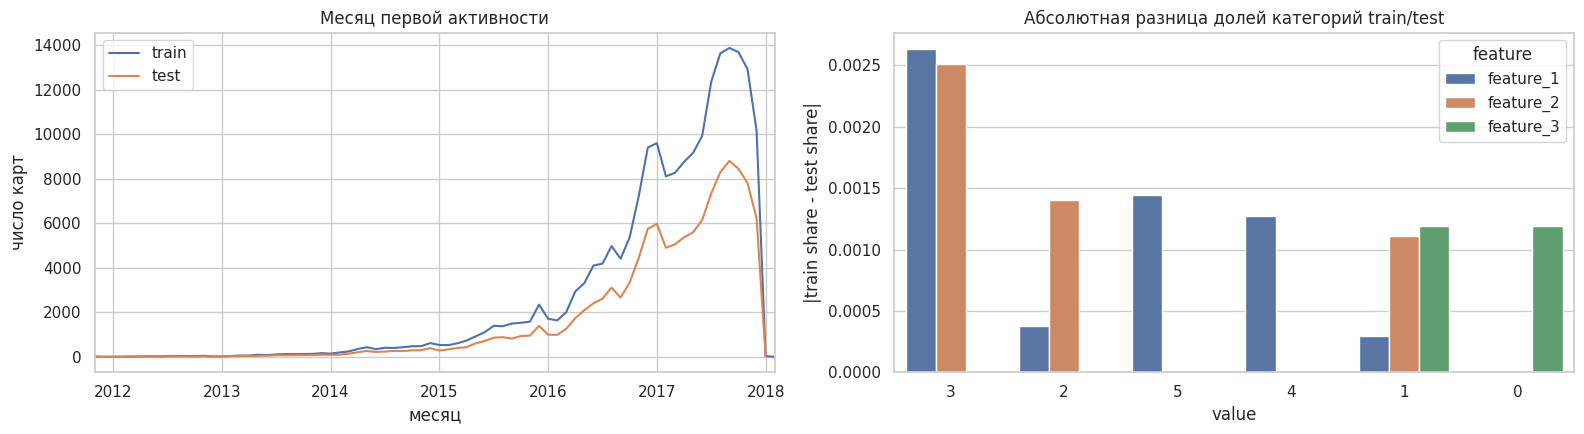

,train,test,abs_difference,feature,value
0,0.364372,0.361737,0.002636,feature_1,3
7,0.187384,0.184877,0.002507,feature_2,3
2,0.201197,0.202640,0.001444,feature_1,5
6,0.370642,0.372042,0.001400,feature_2,2
3,0.098481,0.099755,0.001274,feature_1,4
8,0.565569,0.564377,0.001192,feature_3,1
9,0.434431,0.435623,0.001192,feature_3,0
5,0.441974,0.443081,0.001107,feature_2,1
1,0.276336,0.275960,0.000376,feature_1,2
4,0.059614,0.059908,0.000294,feature_1,1


In [9]:
active_train = pd.to_datetime(
    train["first_active_month"],
    format="%Y-%m",
    errors="coerce",
)
active_test = pd.to_datetime(
    test["first_active_month"],
    format="%Y-%m",
    errors="coerce",
)

active_summary = pd.DataFrame(
    {
        "train": [
            active_train.min(),
            active_train.max(),
            int(active_train.isna().sum()),
        ],
        "test": [
            active_test.min(),
            active_test.max(),
            int(active_test.isna().sum()),
        ],
    },
    index=["min", "max", "missing"],
)
display(active_summary)

fig, axes = plt.subplots(1, 2, figsize=(16, 4.5))

active_train.dt.to_period("M").value_counts().sort_index().plot(
    ax=axes[0],
    label="train",
)
active_test.dt.to_period("M").value_counts().sort_index().plot(
    ax=axes[0],
    label="test",
)
axes[0].set_title("Месяц первой активности")
axes[0].set_xlabel("месяц")
axes[0].set_ylabel("число карт")
axes[0].legend()

feature_shift_rows = []
for column in ["feature_1", "feature_2", "feature_3"]:
    train_share = train[column].value_counts(normalize=True).rename("train")
    test_share = test[column].value_counts(normalize=True).rename("test")
    comparison = pd.concat([train_share, test_share], axis=1).fillna(0)
    comparison["abs_difference"] = (comparison["train"] - comparison["test"]).abs()
    comparison["feature"] = column
    comparison["value"] = comparison.index.astype(str)
    feature_shift_rows.append(comparison.reset_index(drop=True))

feature_shift = pd.concat(feature_shift_rows, ignore_index=True)
sns.barplot(
    data=feature_shift,
    x="value",
    y="abs_difference",
    hue="feature",
    ax=axes[1],
)
axes[1].set_title("Абсолютная разница долей категорий train/test")
axes[1].set_ylabel("|train share - test share|")

plt.tight_layout()
plt.show()

display(feature_shift.sort_values("abs_difference", ascending=False).head(15))

Теперь рассматриваю target и отдельно изучаю левый хвост.


,target
count,201917.000000
mean,-0.393636
std,3.850500
min,-33.219281
0.1%,-33.219281
0.5%,-33.219281
1%,-33.219281
5%,-3.107836
50%,-0.023437
95%,2.702680


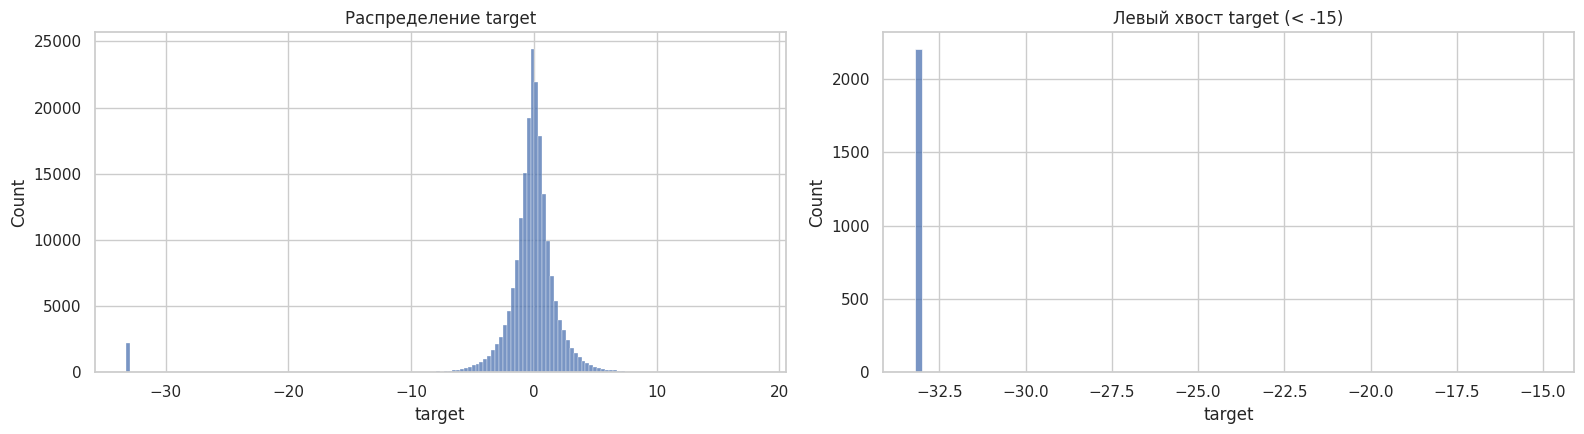

In [10]:
target_summary = train["target"].describe(
    percentiles=[0.001, 0.005, 0.01, 0.05, 0.5, 0.95, 0.99, 0.995, 0.999]
)
display(target_summary.to_frame("target"))

fig, axes = plt.subplots(1, 2, figsize=(16, 4.5))

sns.histplot(train["target"], bins=160, ax=axes[0])
axes[0].set_title("Распределение target")

left_tail = train.loc[train["target"] < -15, "target"]
sns.histplot(left_tail, bins=80, ax=axes[1])
axes[1].set_title("Левый хвост target (< -15)")

plt.tight_layout()
plt.show()

Порог экстремального сегмента не подбираю по RMSE. Сначала показываю фактические значения
в левом хвосте и разрыв между отдельным кластером и основной частью распределения.


In [11]:
left_tail_values = (
    train.loc[train["target"] < -20, "target"]
    .value_counts()
    .sort_index()
    .rename("count")
    .to_frame()
)
display(left_tail_values.head(30))

sorted_unique_target = np.sort(train["target"].unique())
display(
    pd.Series(sorted_unique_target[:30], name="smallest_unique_target")
    .to_frame()
)

EXTREME_THRESHOLD = -30.0
extreme_mask = train["target"] < EXTREME_THRESHOLD

print("Выбранный технический порог:", EXTREME_THRESHOLD)
print("Карт в экстремальном сегменте:", int(extreme_mask.sum()))
print("Доля экстремального сегмента:", f"{extreme_mask.mean():.2%}")
print("Средний target сегмента:", train.loc[extreme_mask, "target"].mean())

,count
target,
-33.219281,2207


,smallest_unique_target
0,-33.219281
1,-17.608147
2,-17.492640
3,-17.441923
4,-17.189636
5,-15.835656
6,-15.553269
7,-15.400146
8,-15.291387
9,-15.103165


Выбранный технический порог: -30.0
Карт в экстремальном сегменте: 2207
Доля экстремального сегмента: 1.09%
Средний target сегмента: -33.21928094999999


Порог `-30` отделяет визуально заметный кластер около `-33.22`.
Он используется только для стратификации и отдельного диагностического классификатора,
а не подбирается как способ напрямую улучшить leaderboard.

Проверяю target по сочетаниям исходных категорий. Редкие группы исключаю из интерпретации,
чтобы не принимать случайное среднее нескольких карт за закономерность.


In [12]:
target_by_card_features = (
    train.groupby(["feature_1", "feature_2", "feature_3"])["target"]
    .agg(["count", "mean", "median", "std"])
    .query("count >= 100")
    .sort_values("mean")
)
display(target_by_card_features.head(15))
display(target_by_card_features.tail(15))

count      mean    median       std
feature_1 feature_2 feature_3                                     
3         3         1          24546 -0.569006 -0.022741  4.571546
5         1         1          24428 -0.561022 -0.015163  4.455991
1         3         0           2696 -0.543918 -0.157942  3.779823
4         1         0           9194 -0.413791 -0.027682  3.683565
2         1         0          24502 -0.409331  0.044959  4.105601
5         2         1          16197 -0.407664 -0.129116  3.594798
4         2         0           6923 -0.405038  0.000000  4.060115
          3         0           3768 -0.381644 -0.057494  3.679458
2         3         0           6826 -0.310319 -0.017809  3.564495
1         2         0           2833 -0.304027  0.000000  3.946988
2         2         0          24469 -0.302688 -0.047135  3.426653
3         2         1          24417 -0.296476 -0.043991  3.491006
          1         1          24610 -0.266980 -0.046852  3.311533
1         1         0           6508 -0.225825 -0.014864  2.957161

count      mean    median       std
feature_1 feature_2 feature_3                                     
3         3         1          24546 -0.569006 -0.022741  4.571546
5         1         1          24428 -0.561022 -0.015163  4.455991
1         3         0           2696 -0.543918 -0.157942  3.779823
4         1         0           9194 -0.413791 -0.027682  3.683565
2         1         0          24502 -0.409331  0.044959  4.105601
5         2         1          16197 -0.407664 -0.129116  3.594798
4         2         0           6923 -0.405038  0.000000  4.060115
          3         0           3768 -0.381644 -0.057494  3.679458
2         3         0           6826 -0.310319 -0.017809  3.564495
1         2         0           2833 -0.304027  0.000000  3.946988
2         2         0          24469 -0.302688 -0.047135  3.426653
3         2         1          24417 -0.296476 -0.043991  3.491006
          1         1          24610 -0.266980 -0.046852  3.311533
1         1         0           6508 -0.225825 -0.014864  2.957161

### Вывод после EDA карт

- исходных признаков мало, и они анонимизированы;
- в target есть небольшой отдельный экстремальный кластер;
- простого правила по `feature_1–3` для него не видно;
- одна дата первой активности в test отсутствует, поэтому пропуск нужно сохранить;
- основной сигнал, вероятно, находится в транзакционном поведении.

Следующий шаг — исследовать транзакции и таблицу продавцов до выбора агрегатов.

## 4. EDA транзакций и продавцов

`historical_transactions.csv` слишком велик для удобного EDA целиком.  
Первые `nrows` брать рискованно: файл может быть сгруппирован по картам.

Поэтому выбираю случайные `card_id` из train и test и затем читаю только их транзакции.


In [13]:
def load_transaction_sample(
    path: Path,
    card_ids: set[str],
    chunksize: int = CHUNK_SIZE,
) -> pd.DataFrame:
    usecols = [
        "authorized_flag",
        "card_id",
        "category_2",
        "category_3",
        "installments",
        "merchant_category_id",
        "merchant_id",
        "month_lag",
        "purchase_amount",
        "purchase_date",
    ]
    parts = []

    for chunk in pd.read_csv(
        path,
        usecols=usecols,
        chunksize=chunksize,
    ):
        selected = chunk.loc[chunk["card_id"].isin(card_ids)]
        if not selected.empty:
            parts.append(selected)

    return (
        pd.concat(parts, ignore_index=True)
        if parts
        else pd.DataFrame()
    )


sampled_train_ids = train["card_id"].sample(
    min(1_500, len(train)),
    random_state=SEED,
)
sampled_test_ids = test["card_id"].sample(
    min(500, len(test)),
    random_state=SEED,
)
eda_card_ids = set(
    pd.concat([sampled_train_ids, sampled_test_ids])
)

hist_sample = load_transaction_sample(
    DATA_DIR / "historical_transactions.csv",
    eda_card_ids,
)
new_sample = load_transaction_sample(
    DATA_DIR / "new_merchant_transactions.csv",
    eda_card_ids,
)

print("Выбрано карт:", len(eda_card_ids))
print("Historical rows:", len(hist_sample))
print("New rows:", len(new_sample))

Выбрано карт: 2000
Historical rows: 173468
New rows: 11973


Сравниваю период наблюдения, покрытие карт и продавцов.


In [14]:
for frame in [hist_sample, new_sample]:
    frame["purchase_date"] = pd.to_datetime(
        frame["purchase_date"],
        format="%Y-%m-%d %H:%M:%S",
        errors="raise",
    )

sample_overview = pd.DataFrame(
    {
        name: [
            len(frame),
            frame["card_id"].nunique(),
            frame["merchant_id"].nunique(),
            frame["purchase_date"].min(),
            frame["purchase_date"].max(),
            frame["month_lag"].min(),
            frame["month_lag"].max(),
            frame["authorized_flag"].eq("Y").mean(),
        ]
        for name, frame in {
            "historical": hist_sample,
            "new": new_sample,
        }.items()
    },
    index=[
        "rows",
        "cards",
        "merchants",
        "purchase_date min",
        "purchase_date max",
        "month_lag min",
        "month_lag max",
        "authorized share",
    ],
)
display(sample_overview)

,historical,new
rows,173468,11973
cards,2000,1791
merchants,35827,9078
purchase_date min,2017-01-01 00:15:24,2017-03-04 15:44:20
purchase_date max,2018-02-28 23:56:19,2018-04-30 23:25:30
month_lag min,-13,1
month_lag max,0,2
authorized share,0.911719,1.0


Проверяю пропуски категорий и специальные значения рассрочки.


In [15]:
missing_transactions = pd.DataFrame(
    {
        name: frame[
            ["category_2", "category_3", "merchant_id"]
        ].isna().mean()
        for name, frame in {
            "historical": hist_sample,
            "new": new_sample,
        }.items()
    }
)
display(missing_transactions)

installment_values = pd.DataFrame(
    {
        name: frame["installments"]
        .value_counts(dropna=False)
        .head(15)
        for name, frame in {
            "historical": hist_sample,
            "new": new_sample,
        }.items()
    }
).fillna(0)
display(installment_values)

,historical,new
category_2,0.081842,0.048526
category_3,0.005696,0.026142
merchant_id,0.004681,0.014032


,historical,new
installments,,
-1,988,313.0
0,94873,6077.0
1,67029,4772.0
2,3901,315.0
3,2960,235.0
4,1015,81.0
5,665,45.0
6,786,41.0
7,67,6.0


Для сравнения сумм использую одинаковое знаковое логарифмирование в обоих периодах:

$$
\operatorname{signed\_log}(x)=\operatorname{sign}(x)\log(1+|x|).
$$

В отличие от отдельного сдвига каждого распределения это преобразование сохраняет
общий масштаб и знак.


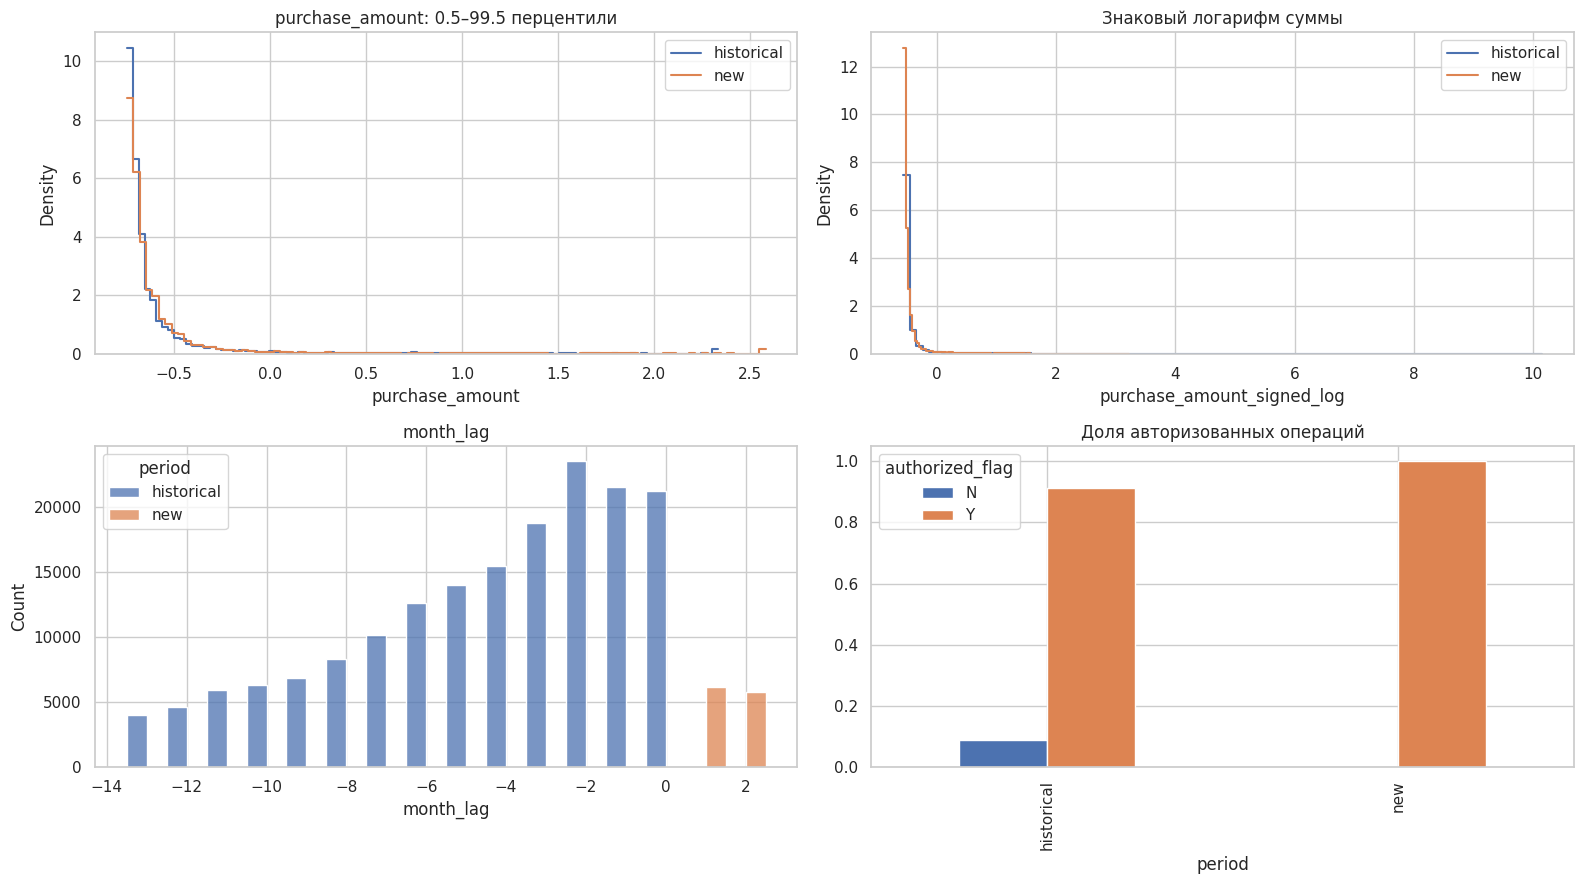

In [16]:
plot_frames = []
for name, frame in {"historical": hist_sample, "new": new_sample}.items():
    current = frame.copy()
    current["period"] = name
    current["purchase_amount_signed_log"] = (
        np.sign(current["purchase_amount"])
        * np.log1p(current["purchase_amount"].abs())
    )
    plot_frames.append(current)

transaction_plot = pd.concat(plot_frames, ignore_index=True)

fig, axes = plt.subplots(2, 2, figsize=(16, 9))

for name, frame in transaction_plot.groupby("period"):
    upper = frame["purchase_amount"].quantile(0.995)
    lower = frame["purchase_amount"].quantile(0.005)

    sns.histplot(
        frame["purchase_amount"].clip(lower=lower, upper=upper),
        bins=100,
        stat="density",
        element="step",
        fill=False,
        label=name,
        ax=axes[0, 0],
    )
    sns.histplot(
        frame["purchase_amount_signed_log"],
        bins=100,
        stat="density",
        element="step",
        fill=False,
        label=name,
        ax=axes[0, 1],
    )

axes[0, 0].set_title("purchase_amount: 0.5–99.5 перцентили")
axes[0, 1].set_title("Знаковый логарифм суммы")
axes[0, 0].legend()
axes[0, 1].legend()

sns.histplot(
    data=transaction_plot,
    x="month_lag",
    hue="period",
    multiple="dodge",
    discrete=True,
    ax=axes[1, 0],
)
axes[1, 0].set_title("month_lag")

authorization = pd.crosstab(
    transaction_plot["period"],
    transaction_plot["authorized_flag"],
    normalize="index",
)
authorization.plot(
    kind="bar",
    ax=axes[1, 1],
    title="Доля авторизованных операций",
)

plt.tight_layout()
plt.show()

Агрегирую выборку до уровня карты, чтобы связать EDA с будущими признаками.


,count,mean,std,min,25%,50%,75%,max
transactions,2000.0,86.734000,109.208743,3.000000,26.000000,54.000000,108.000000,2143.000000
purchase_amount_sum,2000.0,-29.945543,596.088979,-1158.498740,-65.259724,-29.847048,-12.422729,25520.314610
purchase_amount_mean,2000.0,-0.162986,14.014641,-0.741768,-0.679051,-0.622887,-0.506676,622.446698
merchants,2000.0,32.809000,29.736319,1.000000,13.000000,24.000000,43.000000,345.000000
merchant_categories,2000.0,17.901500,11.123384,1.000000,9.000000,16.000000,24.000000,83.000000
authorized_rate,2000.0,0.891612,0.114161,0.181818,0.850000,0.926169,0.970888,1.000000
month_lag_min,2000.0,-7.799000,3.822683,-13.000000,-12.000000,-7.000000,-4.000000,-1.000000
month_lag_max,2000.0,-0.176000,0.695173,-10.000000,0.000000,0.000000,0.000000,0.000000


,count,mean,std,min,25%,50%,75%,max
transactions,1791.0,6.685092,6.598137,1.000000,2.000000,5.000000,9.000000,52.000000
purchase_amount_sum,1791.0,-3.707276,4.451203,-28.108217,-5.148804,-2.656883,-1.231746,37.613147
purchase_amount_mean,1791.0,-0.517719,0.761622,-0.745631,-0.695740,-0.647216,-0.546026,24.017535
merchants,1791.0,6.588498,6.553848,0.000000,2.000000,5.000000,8.000000,52.000000
merchant_categories,1791.0,5.297041,4.258017,1.000000,2.000000,4.000000,7.000000,31.000000
authorized_rate,1791.0,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000
month_lag_min,1791.0,1.165271,0.371529,1.000000,1.000000,1.000000,1.000000,2.000000
month_lag_max,1791.0,1.815187,0.388254,1.000000,2.000000,2.000000,2.000000,2.000000


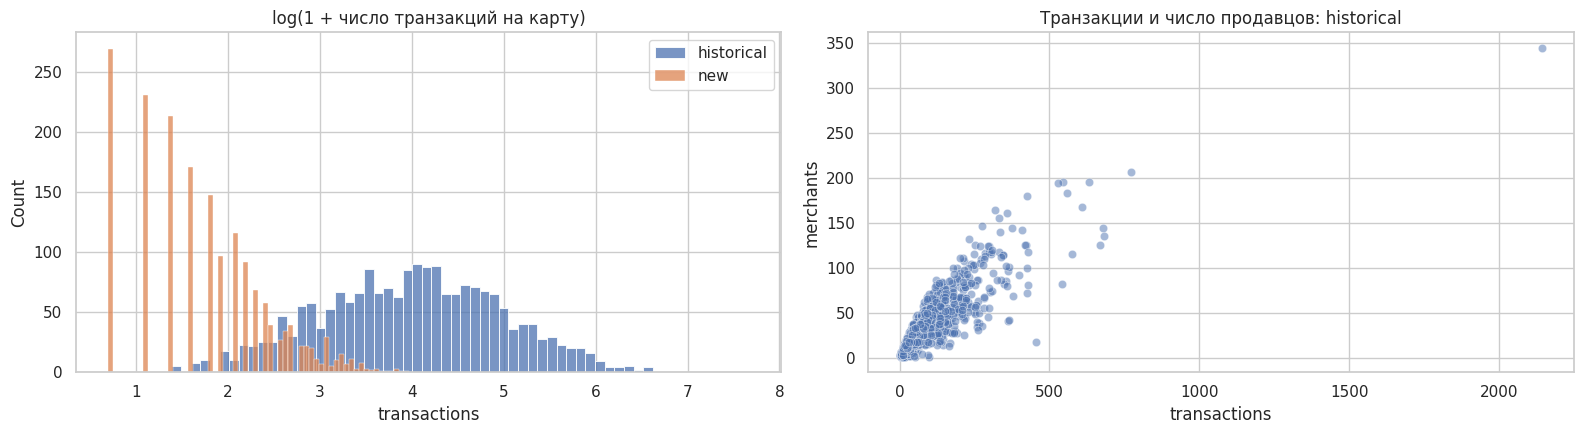

In [17]:
def card_level_sample_summary(frame: pd.DataFrame) -> pd.DataFrame:
    return (
        frame.groupby("card_id")
        .agg(
            transactions=("purchase_amount", "size"),
            purchase_amount_sum=("purchase_amount", "sum"),
            purchase_amount_mean=("purchase_amount", "mean"),
            merchants=("merchant_id", "nunique"),
            merchant_categories=("merchant_category_id", "nunique"),
            authorized_rate=("authorized_flag", lambda x: x.eq("Y").mean()),
            month_lag_min=("month_lag", "min"),
            month_lag_max=("month_lag", "max"),
        )
    )

hist_card_eda = card_level_sample_summary(hist_sample)
new_card_eda = card_level_sample_summary(new_sample)

display(hist_card_eda.describe().T)
display(new_card_eda.describe().T)

fig, axes = plt.subplots(1, 2, figsize=(16, 4.5))

sns.histplot(
    np.log1p(hist_card_eda["transactions"]),
    bins=60,
    label="historical",
    ax=axes[0],
)
sns.histplot(
    np.log1p(new_card_eda["transactions"]),
    bins=60,
    label="new",
    ax=axes[0],
)
axes[0].set_title("log(1 + число транзакций на карту)")
axes[0].legend()

sns.scatterplot(
    data=hist_card_eda.sample(
        min(1_500, len(hist_card_eda)),
        random_state=SEED,
    ),
    x="transactions",
    y="merchants",
    alpha=0.5,
    ax=axes[1],
)
axes[1].set_title("Транзакции и число продавцов: historical")

plt.tight_layout()
plt.show()

Проверяю дубли продавцов и диапазоны числовых полей.


In [18]:
merchant_duplicates = merchants.loc[
    merchants["merchant_id"].duplicated(keep=False)
].sort_values("merchant_id")

print("Строк с повторяющимся merchant_id:", len(merchant_duplicates))
print(
    "Уникальных merchant_id с повторами:",
    merchant_duplicates["merchant_id"].nunique(),
)

merchant_numeric = merchants.select_dtypes(include=np.number).replace(
    [np.inf, -np.inf],
    np.nan,
)
display(
    merchant_numeric.describe(percentiles=[0.01, 0.5, 0.99]).T[
        ["count", "mean", "std", "min", "50%", "99%", "max"]
    ]
)

Строк с повторяющимся merchant_id: 104
Уникальных merchant_id с повторами: 41


,count,mean,std,min,50%,99%,max
merchant_group_id,334696.0,31028.736143,31623.043426,1.000000,19900.000000,109117.000000,1.125860e+05
merchant_category_id,334696.0,423.131663,252.898046,-1.000000,373.000000,884.000000,8.910000e+02
subsector_id,334696.0,25.116404,9.807371,-1.000000,27.000000,40.000000,4.100000e+01
numerical_1,334696.0,0.011476,1.098154,-0.057471,-0.057471,1.062914,1.837351e+02
numerical_2,334696.0,0.008103,1.070497,-0.057471,-0.057471,1.043084,1.820793e+02
avg_sales_lag3,334683.0,13.832993,2395.489999,-82.130000,1.000000,10.760000,8.518446e+05
avg_purchases_lag3,334693.0,1.590762,107.187059,0.333495,1.016667,7.333333,6.185133e+04
active_months_lag3,334696.0,2.994108,0.095247,1.000000,3.000000,3.000000,3.000000e+00
avg_sales_lag6,334683.0,21.650787,3947.108099,-82.130000,1.010000,18.701800,1.513959e+06
avg_purchases_lag6,334693.0,1.887568,97.862790,0.167045,1.026961,12.626111,5.607750e+04


In [19]:
del hist_sample, new_sample
gc.collect()

24016

## 5. Что буду проверять дальше

После EDA получается следующий план.

### Признаки карты

- разобрать `first_active_month` на год, месяц и квартал;
- сохранить отдельный признак пропущенной даты;
- использовать сочетания `feature_1–3` как категории;
- не складывать анонимизированные категории между собой.

### Транзакции

- historical и new обрабатывать отдельно;
- значения рассрочки `-1` и `999` считать служебными;
- пропуски категорий отмечать отдельными флагами;
- вместо среднего кода категории считать доли значений;
- для суммы покупки использовать несколько статистик;
- одобренные и отклонённые операции описать отдельно;
- добавить показатели изменения активности по месяцам.

### Время

`month_lag` показывает положение покупки относительно опорного месяца карты.
Его можно восстановить прямо из даты покупки:

$$
\text{reference month index}
=
\text{purchase month index}
-
\text{month lag}.
$$

Так временные признаки не зависят от произвольно выбранной текущей даты.

### Продавцы

По повторяющимся `merchant_id` объединяю только числовые показатели.
Идентификаторы категории, города и подсектора не усредняю.

## 6. Построение признаков

Сначала создаю признаки самой карты, затем обрабатываю транзакции и свожу их
до одной строки на `card_id`.

In [20]:
train_base = train.drop(columns="target").copy()
test_base = test.copy()

for frame in [train_base, test_base]:
    active = pd.to_datetime(
        frame["first_active_month"],
        format="%Y-%m",
        errors="coerce",
    )

    frame["first_active_missing"] = active.isna().astype("int8")
    frame["first_active_year"] = active.dt.year
    frame["first_active_month_num"] = active.dt.month
    frame["first_active_quarter"] = active.dt.quarter
    frame["first_active_month_index"] = (
        active.dt.year * 12 + active.dt.month - 1
    )

    frame["feature_12_group"] = (
        frame["feature_1"] * 10 + frame["feature_2"]
    )
    frame["feature_13_group"] = (
        frame["feature_1"] * 10 + frame["feature_3"]
    )
    frame["feature_23_group"] = (
        frame["feature_2"] * 10 + frame["feature_3"]
    )
    frame["feature_123_group"] = (
        frame["feature_1"] * 100
        + frame["feature_2"] * 10
        + frame["feature_3"]
    )

    frame.drop(columns="first_active_month", inplace=True)

display(train_base.head())

,card_id,feature_1,feature_2,feature_3,first_active_missing,first_active_year,first_active_month_num,first_active_quarter,first_active_month_index,feature_12_group,feature_13_group,feature_23_group,feature_123_group
0,C_ID_92a2005557,5,2,1,0,2017,6,2,24209,52,51,21,521
1,C_ID_3d0044924f,4,1,0,0,2017,1,1,24204,41,40,10,410
2,C_ID_d639edf6cd,2,2,0,0,2016,8,3,24199,22,20,20,220
3,C_ID_186d6a6901,4,3,0,0,2017,9,3,24212,43,40,30,430
4,C_ID_cdbd2c0db2,1,3,0,0,2017,11,4,24214,13,10,30,130


### 6.2. Профили продавцов

По повторяющимся `merchant_id` объединяю только непрерывные и порядковые показатели.
Категориальные идентификаторы в среднее не включаются.


In [21]:
merchant_frame = merchants.copy()

range_mapping = {
    "A": 5,
    "B": 4,
    "C": 3,
    "D": 2,
    "E": 1,
}
for column in [
    "most_recent_sales_range",
    "most_recent_purchases_range",
]:
    merchant_frame[column] = merchant_frame[column].map(range_mapping)

merchant_frame["category_1_flag"] = (
    merchant_frame["category_1"] == "Y"
).astype("float32")
merchant_frame["category_4_flag"] = (
    merchant_frame["category_4"] == "Y"
).astype("float32")

merchant_numeric_columns = [
    "numerical_1",
    "numerical_2",
    "category_1_flag",
    "category_4_flag",
    "avg_sales_lag3",
    "avg_purchases_lag3",
    "avg_sales_lag6",
    "avg_purchases_lag6",
    "avg_sales_lag12",
    "avg_purchases_lag12",
    "active_months_lag3",
    "active_months_lag6",
    "active_months_lag12",
    "most_recent_sales_range",
    "most_recent_purchases_range",
]

merchant_frame[merchant_numeric_columns] = (
    merchant_frame[merchant_numeric_columns]
    .replace([np.inf, -np.inf], np.nan)
)

merchant_profile_by_id = (
    merchant_frame
    .groupby("merchant_id", sort=False)[merchant_numeric_columns]
    .mean()
)

merchant_maps = {
    column: merchant_profile_by_id[column]
    for column in merchant_numeric_columns
}

print("Продавцов в профиле:", len(merchant_profile_by_id))

Продавцов в профиле: 334633


### 6.3. Временные признаки транзакции

Одинаковые преобразования нужны для historical и new. Сначала разбираю
`purchase_date`, восстанавливаю опорный месяц карты и считаю положение покупки
внутри наблюдаемого периода.

In [22]:
def add_transaction_time_features(result: pd.DataFrame) -> pd.DataFrame:
    result["purchase_date"] = pd.to_datetime(
        result["purchase_date"],
        format="%Y-%m-%d %H:%M:%S",
        errors="raise",
    )
    result["purchase_year"] = result["purchase_date"].dt.year
    result["purchase_month"] = result["purchase_date"].dt.month
    result["purchase_weekday"] = result["purchase_date"].dt.weekday
    result["purchase_hour"] = result["purchase_date"].dt.hour
    result["purchase_weekend"] = (
        result["purchase_weekday"] >= 5
    ).astype("int8")

    result["purchase_month_index"] = (
        result["purchase_year"] * 12
        + result["purchase_month"]
        - 1
    )
    result["reference_month_index"] = (
        result["purchase_month_index"]
        - result["month_lag"]
    )

    reference_year = (
        result["reference_month_index"] // 12
    ).astype("Int64")
    reference_month = (
        result["reference_month_index"] % 12 + 1
    ).astype("Int64")

    reference_start = pd.to_datetime(
        {
            "year": reference_year,
            "month": reference_month,
            "day": 1,
        },
        errors="coerce",
    )
    reference_next_month = (
        reference_start + pd.offsets.MonthBegin(1)
    )
    result["days_before_reference_end"] = (
        reference_next_month - result["purchase_date"]
    ).dt.days

    return result

#### Категории и служебные флаги

Категориальные коды не усредняются как числа. Вместо этого создаются
индикаторы значений и отдельные признаки пропуска.


In [23]:
def add_transaction_category_features(
    result: pd.DataFrame,
) -> pd.DataFrame:
    result["authorized"] = (
        result["authorized_flag"] == "Y"
    ).astype("int8")
    result["category_1_flag"] = (
        result["category_1"] == "Y"
    ).astype("int8")

    result["category_2_missing"] = (
        result["category_2"].isna().astype("int8")
    )
    for value in range(1, 6):
        result[f"category_2_{value}_flag"] = (
            result["category_2"].eq(value).astype("int8")
        )

    category_3 = result["category_3"].astype("string")
    result["category_3_missing"] = (
        category_3.isna().astype("int8")
    )
    for value in ["A", "B", "C"]:
        result[f"category_3_{value}_flag"] = (
            category_3.eq(value)
            .fillna(False)
            .astype("int8")
        )

    return result

#### Рассрочка и сумма покупки

Значения `-1` и `999` не считаю настоящим количеством платежей. Отдельно отмечаю
нулевую и многоплатёжную рассрочку, а для суммы покупки добавляю модуль,
знаковый логарифм и несколько временных взаимодействий. Их польза позднее
проверяется в абляции.

In [24]:
def add_transaction_amount_features(
    result: pd.DataFrame,
) -> pd.DataFrame:
    result["installments_invalid"] = (
        result["installments"].isin([-1, 999]).astype("int8")
    )
    result["installments"] = result["installments"].replace(
        {-1: np.nan, 999: np.nan}
    )
    result["installments_zero"] = (
        result["installments"].fillna(0).eq(0).astype("int8")
    )
    result["installments_multi"] = (
        result["installments"].fillna(0).gt(1).astype("int8")
    )

    installment_denominator = result["installments"].where(
        result["installments"] > 0,
        1,
    )
    result["purchase_amount_per_installment"] = (
        result["purchase_amount"] / installment_denominator
    )
    result["purchase_amount_abs"] = (
        result["purchase_amount"].abs()
    )
    result["purchase_amount_signed_log"] = (
        np.sign(result["purchase_amount"])
        * np.log1p(result["purchase_amount"].abs())
    )

    result["amount_time_interaction"] = (
        result["purchase_amount"]
        * result["days_before_reference_end"]
    )
    result["amount_recency_ratio"] = (
        result["purchase_amount"]
        / (result["days_before_reference_end"].abs() + 1)
    )

    return result

#### Подготовка одного блока транзакций

На этом шаге объединяются временные, категориальные и денежные признаки,
после чего к покупке присоединяются характеристики продавца.

In [25]:
def prepare_transaction_block(block: pd.DataFrame) -> pd.DataFrame:
    result = block.copy()
    result = add_transaction_time_features(result)
    result = add_transaction_category_features(result)
    result = add_transaction_amount_features(result)

    for column, mapping in merchant_maps.items():
        result[f"merchant_{column}"] = (
            result["merchant_id"].map(mapping)
        )

    return result

### 6.4. Изменение активности по месяцам

Одних общих средних недостаточно: две карты могут иметь одинаковую сумму покупок,
но совершенно разную динамику. Поэтому отдельно считаю, как менялись число операций,
сумма и количество продавцов от месяца к месяцу.

In [26]:
def monthly_card_features(
    block: pd.DataFrame,
    prefix: str,
) -> pd.DataFrame:
    monthly = (
        block
        .groupby(["card_id", "month_lag"], sort=False)
        .agg(
            transaction_count=("purchase_amount", "size"),
            purchase_amount_sum=("purchase_amount", "sum"),
            purchase_amount_mean=("purchase_amount", "mean"),
            merchant_count=("merchant_id", "nunique"),
            authorized_rate=("authorized", "mean"),
        )
        .reset_index()
    )

    result = monthly.groupby("card_id", sort=False).agg(
        monthly_active_months=("month_lag", "nunique"),
        monthly_transaction_count_mean=("transaction_count", "mean"),
        monthly_transaction_count_std=("transaction_count", "std"),
        monthly_transaction_count_max=("transaction_count", "max"),
        monthly_purchase_amount_sum_mean=("purchase_amount_sum", "mean"),
        monthly_purchase_amount_sum_std=("purchase_amount_sum", "std"),
        monthly_purchase_amount_sum_min=("purchase_amount_sum", "min"),
        monthly_purchase_amount_sum_max=("purchase_amount_sum", "max"),
        monthly_purchase_amount_mean_mean=("purchase_amount_mean", "mean"),
        monthly_purchase_amount_mean_std=("purchase_amount_mean", "std"),
        monthly_merchant_count_mean=("merchant_count", "mean"),
        monthly_merchant_count_std=("merchant_count", "std"),
        monthly_authorized_rate_mean=("authorized_rate", "mean"),
        monthly_authorized_rate_std=("authorized_rate", "std"),
    )
    result.columns = [
        f"{prefix}_{column}"
        for column in result.columns
    ]
    return result.reset_index()

### 6.5. Агрегация до уровня карты

Для каждой карты считаю количество и сумму покупок, разброс, крайние значения,
разнообразие продавцов и категорий, а также отдельные показатели одобренных
и отклонённых операций.

In [27]:
def transaction_aggregation_spec() -> dict:
    aggregations = {
        "purchase_amount": [
            "count",
            "sum",
            "mean",
            "std",
            "min",
            "max",
            "median",
            "skew",
        ],
        "purchase_amount_abs": ["sum", "mean", "std", "max"],
        "purchase_amount_signed_log": ["mean", "std", "min", "max"],
        "installments": ["mean", "std", "min", "max", "sum"],
        "month_lag": ["mean", "std", "min", "max", "nunique"],
        "days_before_reference_end": ["mean", "std", "min", "max"],
        "reference_month_index": ["median", "min", "max", "nunique"],
        "purchase_year": ["min", "max", "nunique"],
        "purchase_month": ["mean", "std", "nunique"],
        "purchase_weekday": ["mean", "std", "nunique"],
        "purchase_hour": ["mean", "std", "nunique"],
        "purchase_weekend": "mean",
        "authorized": "mean",
        "category_1_flag": "mean",
        "category_2_missing": "mean",
        "category_3_missing": "mean",
        "installments_invalid": "mean",
        "installments_zero": "mean",
        "installments_multi": "mean",
        "merchant_category_id": "nunique",
        "subsector_id": "nunique",
        "city_id": "nunique",
        "state_id": "nunique",
        "merchant_id": "nunique",
        "amount_time_interaction": ["mean", "std", "min", "max"],
        "amount_recency_ratio": ["mean", "std", "min", "max"],
    }

    for value in range(1, 6):
        aggregations[f"category_2_{value}_flag"] = "mean"
    for value in ["A", "B", "C"]:
        aggregations[f"category_3_{value}_flag"] = "mean"

    return aggregations

In [28]:
def aggregate_complete_cards(
    block: pd.DataFrame,
    prefix: str,
) -> pd.DataFrame:
    aggregations = transaction_aggregation_spec()

    merchant_columns = [
        column
        for column in block.columns
        if column.startswith("merchant_")
        and column not in {
            "merchant_id",
            "merchant_category_id",
        }
    ]
    for column in merchant_columns:
        aggregations[column] = ["mean", "std"]

    result = block.groupby("card_id", sort=False).agg(aggregations)
    result.columns = [
        f"{prefix}_{column}_"
        f"{function if isinstance(function, str) else function.__name__}"
        for column, function in result.columns.to_flat_index()
    ]
    result = result.reset_index()

    for authorization, label in [
        (1, "authorized"),
        (0, "unauthorized"),
    ]:
        subset = block.loc[
            block["authorized"] == authorization
        ]
        statistics = (
            subset
            .groupby("card_id", sort=False)["purchase_amount"]
            .agg(["count", "sum", "mean"])
        )
        statistics.columns = [
            f"{prefix}_{label}_purchase_amount_{stat}"
            for stat in statistics.columns
        ]
        result = result.merge(
            statistics,
            left_on="card_id",
            right_index=True,
            how="left",
            validate="one_to_one",
        )

    result = result.merge(
        monthly_card_features(block, prefix),
        on="card_id",
        how="left",
        validate="one_to_one",
    )

    result[f"{prefix}_active_span_days"] = (
        result[f"{prefix}_days_before_reference_end_max"]
        - result[f"{prefix}_days_before_reference_end_min"]
    ).abs()
    result[f"{prefix}_transactions_per_active_day"] = (
        result[f"{prefix}_purchase_amount_count"]
        / (result[f"{prefix}_active_span_days"] + 1)
    )

    return result

### 6.6. Чтение больших файлов

Последнюю карту каждого чанка переношу в следующий чанк. Благодаря этому вся история
карты агрегируется целиком, а медиана, стандартное отклонение и число уникальных
значений не искажаются на границе частей файла.

In [29]:
def transaction_read_options():
    usecols = [
        "authorized_flag",
        "card_id",
        "city_id",
        "category_1",
        "category_2",
        "category_3",
        "installments",
        "merchant_category_id",
        "merchant_id",
        "month_lag",
        "purchase_amount",
        "purchase_date",
        "state_id",
        "subsector_id",
    ]
    dtypes = {
        "authorized_flag": "category",
        "card_id": "string",
        "city_id": "int16",
        "category_1": "category",
        "category_2": "float32",
        "category_3": "category",
        "installments": "int16",
        "merchant_category_id": "int32",
        "merchant_id": "string",
        "month_lag": "int16",
        "purchase_amount": "float32",
        "state_id": "int16",
        "subsector_id": "int16",
    }
    return usecols, dtypes

In [30]:
def aggregate_transaction_file(
    path: Path,
    prefix: str,
    chunksize: int = CHUNK_SIZE,
) -> pd.DataFrame:
    usecols, dtypes = transaction_read_options()

    parts = []
    carry = None
    finalized_cards = set()

    reader = pd.read_csv(
        path,
        usecols=usecols,
        dtype=dtypes,
        chunksize=chunksize,
    )

    for chunk_number, raw_chunk in enumerate(reader, start=1):
        chunk = (
            raw_chunk
            if carry is None
            else pd.concat([carry, raw_chunk], ignore_index=True)
        )

        last_card = chunk["card_id"].iloc[-1]
        complete = chunk.loc[
            chunk["card_id"] != last_card
        ]
        carry = chunk.loc[
            chunk["card_id"] == last_card
        ].copy()

        if not complete.empty:
            complete_ids = set(
                complete["card_id"].astype(str).unique()
            )
            repeated = complete_ids.intersection(finalized_cards)
            if repeated:
                example = next(iter(repeated))
                raise ValueError(
                    f"{path.name} не сгруппирован по card_id: "
                    f"карта {example} появилась повторно."
                )
            finalized_cards.update(complete_ids)

            prepared = prepare_transaction_block(complete)
            parts.append(
                aggregate_complete_cards(prepared, prefix)
            )

        print(f"{prefix}: обработан чанк {chunk_number}")

    if carry is not None and not carry.empty:
        carry_id = str(carry["card_id"].iloc[0])
        if carry_id in finalized_cards:
            raise ValueError(
                f"Карта {carry_id} появилась после завершения её блока."
            )

        prepared = prepare_transaction_block(carry)
        parts.append(
            aggregate_complete_cards(prepared, prefix)
        )

    if not parts:
        return pd.DataFrame(columns=["card_id"])

    result = pd.concat(parts, ignore_index=True)

    if not result["card_id"].is_unique:
        raise AssertionError(
            f"После агрегации {prefix} card_id должен быть уникальным."
        )

    return result

### 6.7. Изменение поведения между периодами

После раздельной агрегации historical и new добавляю разности и отношения:
как изменились число покупок, средняя сумма, разнообразие продавцов
и помесячная активность.

In [31]:
def add_cross_period_features(
    features: pd.DataFrame,
) -> pd.DataFrame:
    result = features.copy()

    basic_pairs = {
        "transaction_count_ratio": "purchase_amount_count",
        "purchase_amount_sum_ratio": "purchase_amount_sum",
        "merchant_diversity_ratio": "merchant_id_nunique",
    }
    for feature_name, suffix in basic_pairs.items():
        historical = result[f"hist_{suffix}"].fillna(0)
        new = result[f"new_{suffix}"].fillna(0)
        result[f"cross_basic_{feature_name}"] = (
            new / (historical.abs() + 1)
        )

    for suffix in [
        "purchase_amount_mean",
        "purchase_amount_std",
        "active_span_days",
        "transactions_per_active_day",
        "authorized_mean",
    ]:
        hist_column = f"hist_{suffix}"
        new_column = f"new_{suffix}"
        result[f"cross_basic_new_minus_hist_{suffix}"] = (
            result[new_column] - result[hist_column]
        )
        result[f"cross_basic_new_to_hist_{suffix}_ratio"] = (
            result[new_column]
            / (result[hist_column].abs() + 1)
        )

    for suffix in [
        "monthly_active_months",
        "monthly_transaction_count_mean",
        "monthly_purchase_amount_sum_mean",
        "monthly_authorized_rate_mean",
    ]:
        hist_column = f"hist_{suffix}"
        new_column = f"new_{suffix}"
        result[f"cross_monthly_new_minus_hist_{suffix}"] = (
            result[new_column] - result[hist_column]
        )
        result[f"cross_monthly_new_to_hist_{suffix}_ratio"] = (
            result[new_column]
            / (result[hist_column].abs() + 1)
        )

    for suffix in [
        "amount_time_interaction_mean",
        "amount_recency_ratio_mean",
    ]:
        hist_column = f"hist_{suffix}"
        new_column = f"new_{suffix}"
        result[f"cross_experimental_new_minus_hist_{suffix}"] = (
            result[new_column] - result[hist_column]
        )

    return result

### 6.8. Полная таблица признаков

Historical и new читаются по одному разу, агрегируются отдельно и затем
объединяются с таблицами карт.

#### Агрегация двух периодов

Сначала отдельно обрабатываю historical и new, затем объединяю их по `card_id`.

In [32]:
historical_features = aggregate_transaction_file(
    DATA_DIR / "historical_transactions.csv",
    prefix="hist",
)
new_features = aggregate_transaction_file(
    DATA_DIR / "new_merchant_transactions.csv",
    prefix="new",
)

transaction_features = historical_features.merge(
    new_features,
    on="card_id",
    how="outer",
    validate="one_to_one",
)
transaction_features = add_cross_period_features(
    transaction_features
).set_index("card_id")

full_train_features = train_base.join(
    transaction_features,
    on="card_id",
    how="left",
)
full_test_features = test_base.join(
    transaction_features,
    on="card_id",
    how="left",
)

hist: обработан чанк 1
hist: обработан чанк 2
hist: обработан чанк 3
hist: обработан чанк 4
hist: обработан чанк 5
hist: обработан чанк 6
hist: обработан чанк 7
hist: обработан чанк 8
hist: обработан чанк 9
hist: обработан чанк 10
hist: обработан чанк 11
hist: обработан чанк 12
hist: обработан чанк 13
hist: обработан чанк 14
hist: обработан чанк 15
hist: обработан чанк 16
hist: обработан чанк 17
hist: обработан чанк 18
hist: обработан чанк 19
hist: обработан чанк 20
hist: обработан чанк 21
hist: обработан чанк 22
hist: обработан чанк 23
hist: обработан чанк 24
hist: обработан чанк 25
hist: обработан чанк 26
hist: обработан чанк 27
hist: обработан чанк 28
hist: обработан чанк 29
hist: обработан чанк 30
hist: обработан чанк 31
hist: обработан чанк 32
hist: обработан чанк 33
hist: обработан чанк 34
hist: обработан чанк 35
hist: обработан чанк 36
hist: обработан чанк 37
hist: обработан чанк 38
hist: обработан чанк 39
new: обработан чанк 1
new: обработан чанк 2
new: обработан чанк 3


#### Нормировка активности на возраст карты

После объединения транзакций с базовой таблицей можно сравнить
восстановленный опорный месяц с месяцем первой активности карты.


In [33]:
for frame in [full_train_features, full_test_features]:
    reference_month = (
        frame["hist_reference_month_index_median"]
        .combine_first(
            frame["new_reference_month_index_median"]
        )
    )
    frame["age_normalized_months_active_at_reference"] = (
        reference_month
        - frame["first_active_month_index"]
    )

    active_months = (
        frame["age_normalized_months_active_at_reference"]
        .clip(lower=0)
        + 1
    )

    for prefix in ["hist", "new"]:
        count_column = f"{prefix}_purchase_amount_count"
        sum_column = f"{prefix}_purchase_amount_sum"

        frame[
            f"age_normalized_{prefix}_transactions_per_month_active"
        ] = frame[count_column] / active_months
        frame[
            f"age_normalized_{prefix}_amount_per_month_active"
        ] = frame[sum_column] / active_months

full_train_features["target"] = train["target"].to_numpy()

#### Снижение расхода памяти

После объединения перевожу числовые признаки в `float32` и удаляю большие
временные таблицы, которые дальше не понадобятся.

In [34]:
feature_columns_for_downcast = [
    column
    for column in full_train_features.columns
    if column not in {"card_id", "target"}
]

for frame in [full_train_features, full_test_features]:
    numeric_columns = [
        column
        for column in feature_columns_for_downcast
        if column in frame.columns
        and pd.api.types.is_numeric_dtype(frame[column])
    ]
    frame[numeric_columns] = frame[numeric_columns].astype("float32")

full_train_features["target"] = (
    full_train_features["target"].astype("float32")
)

del historical_features, new_features, transaction_features
gc.collect()

print("Полная таблица признаков рассчитана.")

Полная таблица признаков рассчитана.


Проверяю итоговое объединение и согласованность опорного месяца.


In [35]:
assert full_train_features["card_id"].equals(train["card_id"])
assert full_test_features["card_id"].equals(test["card_id"])
assert full_train_features["card_id"].is_unique
assert full_test_features["card_id"].is_unique
assert (
    set(full_train_features.columns) - {"target"}
    == set(full_test_features.columns)
)

reference_consistency = pd.DataFrame(
    {
        "historical": full_train_features[
            "hist_reference_month_index_nunique"
        ].value_counts(dropna=False).sort_index(),
        "new": full_train_features[
            "new_reference_month_index_nunique"
        ].value_counts(dropna=False).sort_index(),
    }
).fillna(0)

display(reference_consistency.head(10))
print("Train full:", full_train_features.shape)
print("Test full:", full_test_features.shape)

,historical,new
1.0,201917.0,179986
NaN,0.0,21931


Train full: (201917, 296)
Test full: (123623, 295)


Проверка ниже показывает, насколько согласованно восстановился опорный месяц карты.
После этого формирую несколько последовательных наборов признаков и сравниваю их
одной и той же LightGBM.

## 7. Наборы признаков и абляция

In [36]:
all_feature_columns = [
    column
    for column in full_train_features.columns
    if column not in {"card_id", "target"}
]

raw_columns = [
    "feature_1",
    "feature_2",
    "feature_3",
    "first_active_missing",
    "first_active_year",
    "first_active_month_num",
    "first_active_quarter",
    "first_active_month_index",
    "feature_12_group",
    "feature_13_group",
    "feature_23_group",
    "feature_123_group",
]

robust_tokens = (
    "purchase_amount_abs",
    "purchase_amount_signed_log",
    "purchase_hour",
    "installments_zero",
    "installments_multi",
)
monthly_token = "_monthly_"
experimental_tokens = (
    "amount_time_interaction",
    "amount_recency_ratio",
)

#### Транзакционные блоки

Сначала выделяю обычные агрегаты historical и new. Более сложные признаки —
помесячную динамику, нормировку по возрасту карты и взаимодействия суммы со временем —
оставляю отдельными группами, чтобы увидеть их собственный вклад.

In [37]:
hist_basic_columns = [
    column
    for column in all_feature_columns
    if column.startswith("hist_")
    and monthly_token not in column
    and not any(token in column for token in robust_tokens)
    and not any(token in column for token in experimental_tokens)
]

new_basic_columns = [
    column
    for column in all_feature_columns
    if column.startswith("new_")
    and monthly_token not in column
    and not any(token in column for token in robust_tokens)
    and not any(token in column for token in experimental_tokens)
]

cross_basic_columns = [
    column
    for column in all_feature_columns
    if column.startswith("cross_basic_")
]

robust_columns = [
    column
    for column in all_feature_columns
    if any(token in column for token in robust_tokens)
]

monthly_columns = [
    column
    for column in all_feature_columns
    if monthly_token in column
    or column.startswith("cross_monthly_")
]

age_normalized_columns = [
    column
    for column in all_feature_columns
    if column.startswith("age_normalized_")
]

experimental_columns = [
    column
    for column in all_feature_columns
    if any(token in column for token in experimental_tokens)
    or column.startswith("cross_experimental_")
]

Проверяю размер каждого блока до построения последовательных наборов.


In [38]:
block_summary = pd.DataFrame(
    {
        "block": [
            "raw",
            "historical basic",
            "new basic",
            "cross-period basic",
            "robust amount/calendar",
            "monthly behavior",
            "age normalization",
            "experimental amount-time",
        ],
        "features": [
            len(raw_columns),
            len(hist_basic_columns),
            len(new_basic_columns),
            len(cross_basic_columns),
            len(robust_columns),
            len(monthly_columns),
            len(age_normalized_columns),
            len(experimental_columns),
        ],
    }
)
display(block_summary)

,block,features
0,raw,12
1,historical basic,92
2,new basic,92
3,cross-period basic,13
4,robust amount/calendar,26
5,monthly behavior,36
6,age normalization,5
7,experimental amount-time,18


Собираю последовательные наборы: каждый следующий содержит предыдущий
и добавляет только одну новую группу признаков.

In [39]:
def ordered_unique(columns):
    return list(dict.fromkeys(columns))

feature_sets = {}

feature_sets["raw"] = ordered_unique(raw_columns)
feature_sets["raw+historical"] = ordered_unique(
    feature_sets["raw"] + hist_basic_columns
)
feature_sets["raw+historical+new"] = ordered_unique(
    feature_sets["raw+historical"] + new_basic_columns
)
feature_sets["+cross-period"] = ordered_unique(
    feature_sets["raw+historical+new"] + cross_basic_columns
)
feature_sets["+robust"] = ordered_unique(
    feature_sets["+cross-period"] + robust_columns
)
feature_sets["+monthly"] = ordered_unique(
    feature_sets["+robust"] + monthly_columns
)
feature_sets["+age-normalized"] = ordered_unique(
    feature_sets["+monthly"] + age_normalized_columns
)
feature_sets["+experimental"] = ordered_unique(
    feature_sets["+age-normalized"] + experimental_columns
)

display(
    pd.DataFrame(
        {
            "feature_set": list(feature_sets),
            "feature_count": [
                len(columns)
                for columns in feature_sets.values()
            ],
        }
    )
)

,feature_set,feature_count
0,raw,12
1,raw+historical,104
2,raw+historical+new,196
3,+cross-period,209
4,+robust,235
5,+monthly,271
6,+age-normalized,276
7,+experimental,294


### 7.1. Подготовка матриц и единые фолды

Пропуски не заполняются для бустингов: LightGBM, XGBoost и CatBoost умеют
обрабатывать их напрямую. Полностью пустые столбцы удаляются.

Для LightGBM и XGBoost анонимизированные категории и их комбинации
one-hot кодируются. Это не создаёт искусственного порядка между кодами категорий.
CatBoost позднее получит исходные категориальные столбцы отдельно.


In [40]:
TREE_CATEGORICAL_COLUMNS = [
    "feature_1",
    "feature_2",
    "feature_3",
    "feature_12_group",
    "feature_13_group",
    "feature_23_group",
    "feature_123_group",
    "first_active_year",
    "first_active_month_num",
    "first_active_quarter",
]


def prepare_numeric_matrix(columns):
    train_selected = (
        full_train_features[columns]
        .replace([np.inf, -np.inf], np.nan)
        .reset_index(drop=True)
    )
    test_selected = (
        full_test_features[columns]
        .replace([np.inf, -np.inf], np.nan)
        .reset_index(drop=True)
    )

    all_missing = [
        column
        for column in train_selected.columns
        if train_selected[column].isna().all()
    ]
    train_selected = train_selected.drop(
        columns=all_missing
    )
    test_selected = test_selected.drop(
        columns=all_missing
    )

    categorical_columns = [
        column
        for column in TREE_CATEGORICAL_COLUMNS
        if column in train_selected.columns
    ]

    for frame in [train_selected, test_selected]:
        for column in categorical_columns:
            frame[column] = (
                frame[column]
                .astype("Int64")
                .astype("string")
                .fillna("__MISSING__")
            )

    X = pd.get_dummies(
        train_selected,
        columns=categorical_columns,
        dtype="float32",
    )
    X_test = pd.get_dummies(
        test_selected,
        columns=categorical_columns,
        dtype="float32",
    )

    X_test = X_test.reindex(
        columns=X.columns,
        fill_value=0,
    )

    X = X.astype("float32")
    X_test = X_test.astype("float32")

    assert list(X.columns) == list(X_test.columns)
    return X, X_test

Целевая переменная и фолды задаются один раз и используются во всех экспериментах.
Стратификация поддерживает одинаковую долю экстремального сегмента.


In [41]:
y = (
    full_train_features["target"]
    .astype("float32")
    .reset_index(drop=True)
)
test_ids = (
    full_test_features[["card_id"]]
    .copy()
    .reset_index(drop=True)
)

extreme_indicator = (
    y < EXTREME_THRESHOLD
).astype("int8")

primary_splitter = StratifiedKFold(
    n_splits=N_SPLITS,
    shuffle=True,
    random_state=SEED,
)
primary_folds = list(
    primary_splitter.split(
        np.zeros(len(y)),
        extreme_indicator,
    )
)

fold_audit = []
for fold_number, (
    _,
    valid_index,
) in enumerate(primary_folds, start=1):
    fold_audit.append(
        {
            "fold": fold_number,
            "validation_rows": len(valid_index),
            "extreme_rows": int(
                extreme_indicator.iloc[
                    valid_index
                ].sum()
            ),
            "target_mean": float(
                y.iloc[valid_index].mean()
            ),
            "target_std": float(
                y.iloc[valid_index].std()
            ),
        }
    )

display(pd.DataFrame(fold_audit))

,fold,validation_rows,extreme_rows,target_mean,target_std
0,1,40384,442,-0.399318,3.848991
1,2,40384,442,-0.407176,3.855587
2,3,40383,441,-0.379357,3.855860
3,4,40383,441,-0.388627,3.846673
4,5,40383,441,-0.393703,3.845508


### 7.2. Общая схема кросс-валидации

Все модели обучаются на одних и тех же пяти фолдах. Для каждой сохраняю
OOF-прогноз, средний прогноз для test, RMSE по фолдам, время обучения
и число деревьев до early stopping.

In [42]:
def fold_scores_from_prediction(
    prediction,
    folds=primary_folds,
):
    return [
        root_mean_squared_error(
            y.iloc[valid_index],
            prediction[valid_index],
        )
        for _, valid_index in folds
    ]

Ниже находится общий код обучения одного фолда и сборки результатов.
Он используется для LightGBM, XGBoost и CatBoost.

#### Обучение одного фолда

In [43]:
def fit_regression_fold(
    model,
    X_train,
    y_train,
    X_valid,
    y_valid,
    X_test,
    fit_kwargs,
    importance_getter,
):
    model.fit(
        X_train,
        y_train,
        **fit_kwargs,
    )

    valid_prediction = model.predict(
        X_valid
    )
    test_prediction = model.predict(
        X_test
    )
    score = root_mean_squared_error(
        y_valid,
        valid_prediction,
    )

    best_iteration = getattr(
        model,
        "best_iteration_",
        None,
    )
    if best_iteration is None:
        best_iteration = getattr(
            model,
            "best_iteration",
            None,
        )
    if (
        best_iteration is None
        and hasattr(model, "get_best_iteration")
    ):
        best_iteration = model.get_best_iteration()
    if best_iteration is not None and best_iteration < 0:
        best_iteration = None

    importance = None
    if importance_getter is not None:
        importance = np.asarray(
            importance_getter(model),
            dtype=float,
        )

    return {
        "valid_prediction": valid_prediction,
        "test_prediction": test_prediction,
        "score": float(score),
        "best_iteration": (
            np.nan
            if best_iteration is None
            else float(best_iteration)
        ),
        "importance": importance,
    }

#### Сводка по пяти фолдам

In [44]:
def build_cv_importance(
    columns,
    fold_importances,
):
    if not fold_importances:
        return None

    return pd.DataFrame(
        {
            "feature": columns,
            "importance_mean": np.mean(
                fold_importances,
                axis=0,
            ),
            "importance_std": np.std(
                fold_importances,
                axis=0,
                ddof=1,
            ),
        }
    ).sort_values(
        "importance_mean",
        ascending=False,
    )


def build_cv_metadata(
    name,
    oof,
    fold_scores,
    runtime_seconds,
):
    return {
        "name": name,
        "OOF_RMSE": float(
            root_mean_squared_error(y, oof)
        ),
        "fold_mean_RMSE": float(
            np.mean(fold_scores)
        ),
        "fold_std_RMSE": float(
            np.std(fold_scores, ddof=1)
        ),
        "fold_min_RMSE": float(
            np.min(fold_scores)
        ),
        "fold_max_RMSE": float(
            np.max(fold_scores)
        ),
        "runtime_seconds": float(
            runtime_seconds
        ),
    }

#### Основной цикл

In [45]:
def run_regression_cv(
    name,
    model_factory,
    X,
    X_test,
    folds=primary_folds,
    fit_kwargs_builder=None,
    importance_getter=None,
):
    start_time = time.perf_counter()
    oof = np.zeros(len(X), dtype="float32")
    test_prediction = np.zeros(
        len(X_test),
        dtype="float32",
    )
    fold_scores = []
    best_iterations = []
    fold_importances = []

    for fold_number, (
        train_index,
        valid_index,
    ) in enumerate(folds, start=1):
        model = model_factory(fold_number)

        fit_kwargs = {}
        if fit_kwargs_builder is not None:
            fit_kwargs = fit_kwargs_builder(
                model,
                X.iloc[train_index],
                y.iloc[train_index],
                X.iloc[valid_index],
                y.iloc[valid_index],
            )

        fold_result = fit_regression_fold(
            model=model,
            X_train=X.iloc[train_index],
            y_train=y.iloc[train_index],
            X_valid=X.iloc[valid_index],
            y_valid=y.iloc[valid_index],
            X_test=X_test,
            fit_kwargs=fit_kwargs,
            importance_getter=importance_getter,
        )

        oof[valid_index] = fold_result["valid_prediction"]
        test_prediction += (
            fold_result["test_prediction"]
            / len(folds)
        )
        fold_scores.append(fold_result["score"])
        best_iterations.append(
            fold_result["best_iteration"]
        )

        if fold_result["importance"] is not None:
            fold_importances.append(
                fold_result["importance"]
            )

        print(
            f"{name} | fold {fold_number}/{len(folds)} "
            f"| RMSE={fold_result['score']:.5f}"
        )

        del model
        gc.collect()

    runtime_seconds = time.perf_counter() - start_time
    importance = build_cv_importance(
        X.columns,
        fold_importances,
    )
    metadata = build_cv_metadata(
        name,
        oof,
        fold_scores,
        runtime_seconds,
    )

    return {
        **metadata,
        "oof": oof,
        "test": test_prediction,
        "fold_scores": fold_scores,
        "best_iterations": best_iterations,
        "importance": importance,
    }

### 7.3. Простые baseline

`DummyRegressor` задаёт нижнюю границу.  
Для линейной модели использую `RidgeCV`, поэтому коэффициент регуляризации
не задаётся произвольно, а выбирается внутри каждого фолда.
Категориальные признаки one-hot кодируются.


DummyRegressor и RidgeCV остаются на CPU. Они обучаются быстро и используются
только как простые ориентиры; перенос этих операций на GPU не сократил бы
общее время работы заметно.


In [46]:
from sklearn.dummy import DummyRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import RidgeCV
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

X_raw, X_test_raw = prepare_numeric_matrix(
    feature_sets["raw"]
)

Создаю массивы OOF и запускаю одинаковые фолды для двух простых моделей.


In [47]:
dummy_oof = np.zeros(
    len(y),
    dtype="float32",
)
ridge_oof = np.zeros(
    len(y),
    dtype="float32",
)
ridge_test = np.zeros(
    len(X_test_raw),
    dtype="float32",
)
ridge_alphas = []
ridge_fold_scores = []

for fold_number, (
    train_index,
    valid_index,
) in enumerate(primary_folds, start=1):
    dummy = DummyRegressor(
        strategy="mean"
    )
    dummy.fit(
        X_raw.iloc[train_index],
        y.iloc[train_index],
    )
    dummy_oof[valid_index] = (
        dummy.predict(
            X_raw.iloc[valid_index]
        )
    )

    ridge = make_pipeline(
        SimpleImputer(
            strategy="median"
        ),
        StandardScaler(),
        RidgeCV(
            alphas=np.logspace(
                -3,
                4,
                30,
            )
        ),
    )
    ridge.fit(
        X_raw.iloc[train_index],
        y.iloc[train_index],
    )
    ridge_oof[valid_index] = (
        ridge.predict(
            X_raw.iloc[valid_index]
        )
    )
    ridge_test += (
        ridge.predict(X_test_raw)
        / len(primary_folds)
    )

    selected_alpha = (
        ridge.named_steps[
            "ridgecv"
        ].alpha_
    )
    ridge_alphas.append(
        float(selected_alpha)
    )
    ridge_fold_scores.append(
        root_mean_squared_error(
            y.iloc[valid_index],
            ridge_oof[valid_index],
        )
    )

Считаю общие метрики и показываю выбранный `alpha` по фолдам.


In [48]:
dummy_score = root_mean_squared_error(
    y,
    dummy_oof,
)
ridge_score = root_mean_squared_error(
    y,
    ridge_oof,
)

baseline_table = pd.DataFrame(
    {
        "model": [
            "DummyRegressor",
            "RidgeCV",
        ],
        "OOF_RMSE": [
            dummy_score,
            ridge_score,
        ],
        "fold_mean_RMSE": [
            np.mean(
                fold_scores_from_prediction(
                    dummy_oof
                )
            ),
            np.mean(
                ridge_fold_scores
            ),
        ],
        "fold_std_RMSE": [
            np.std(
                fold_scores_from_prediction(
                    dummy_oof
                ),
                ddof=1,
            ),
            np.std(
                ridge_fold_scores,
                ddof=1,
            ),
        ],
    }
)
display(baseline_table)

display(
    pd.DataFrame(
        {
            "fold": range(
                1,
                N_SPLITS + 1,
            ),
            "selected_alpha": (
                ridge_alphas
            ),
            "valid_RMSE": (
                ridge_fold_scores
            ),
        }
    )
)

,model,OOF_RMSE,fold_mean_RMSE,fold_std_RMSE
0,DummyRegressor,3.850497,3.850494,0.004930
1,RidgeCV,3.842995,3.842991,0.005646


,fold,selected_alpha,valid_RMSE
0,1,10000.0,3.842219
1,2,10000.0,3.848701
2,3,10000.0,3.848917
3,4,10000.0,3.837873
4,5,10000.0,3.837248


### 7.4. Абляция групп признаков

Для всех наборов используется одна заранее зафиксированная консервативная LightGBM.
Она не считается оптимальной: её задача — сравнить признаки при неизменной модели.


Набор признаков выбираю на отдельном трёхфолдном разбиении.
Основные пять фолдов пока не используются: на них позднее сравниваются уже выбранные модели.


In [49]:
feature_selection_splitter = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=SEED + 50,
)
feature_selection_folds = list(
    feature_selection_splitter.split(
        np.zeros(len(y)),
        extreme_indicator,
    )
)

In [50]:
import lightgbm as lgb

ablation_lgb_params = {
    "n_estimators": 3_000,
    "learning_rate": 0.03,
    "num_leaves": 31,
    "random_state": SEED,
    "n_jobs": -1,
    "verbosity": -1,
    **LIGHTGBM_GPU_PARAMS,
}

ablation_results = {}
ablation_rows = []

for feature_set_name, columns in feature_sets.items():
    X_current, X_test_current = prepare_numeric_matrix(columns)

    result = run_regression_cv(
        name=f"ablation_{len(ablation_results) + 1}",
        model_factory=lambda fold_number: lgb.LGBMRegressor(
            **ablation_lgb_params
        ),
        X=X_current,
        X_test=X_test_current,
        folds=feature_selection_folds,
        fit_kwargs_builder=lambda model, X_train, y_train, X_valid, y_valid: {
            "eval_set": [(X_valid, y_valid)],
            "callbacks": [
                lgb.early_stopping(150, verbose=False)
            ],
        },
    )

    ablation_results[feature_set_name] = result
    ablation_rows.append(
        {
            "feature_set": feature_set_name,
            "feature_count": X_current.shape[1],
            "OOF_RMSE": result["OOF_RMSE"],
            "fold_mean_RMSE": result["fold_mean_RMSE"],
            "fold_std_RMSE": result["fold_std_RMSE"],
            "runtime_seconds": result["runtime_seconds"],
        }
    )

ablation_table = pd.DataFrame(ablation_rows)
ablation_table["improvement_vs_previous"] = (
    ablation_table["OOF_RMSE"].shift(1)
    - ablation_table["OOF_RMSE"]
)
display(ablation_table)

ablation_1 | fold 1/3 | RMSE=3.84290
ablation_1 | fold 2/3 | RMSE=3.83907
ablation_1 | fold 3/3 | RMSE=3.84574
ablation_2 | fold 1/3 | RMSE=3.74327
ablation_2 | fold 2/3 | RMSE=3.74983
ablation_2 | fold 3/3 | RMSE=3.74466
ablation_3 | fold 1/3 | RMSE=3.69183
ablation_3 | fold 2/3 | RMSE=3.67090
ablation_3 | fold 3/3 | RMSE=3.68990
ablation_4 | fold 1/3 | RMSE=3.68946
ablation_4 | fold 2/3 | RMSE=3.68634
ablation_4 | fold 3/3 | RMSE=3.69021
ablation_5 | fold 1/3 | RMSE=3.68028
ablation_5 | fold 2/3 | RMSE=3.67808
ablation_5 | fold 3/3 | RMSE=3.69027
ablation_6 | fold 1/3 | RMSE=3.68520
ablation_6 | fold 2/3 | RMSE=3.67775
ablation_6 | fold 3/3 | RMSE=3.67136
ablation_7 | fold 1/3 | RMSE=3.69466
ablation_7 | fold 2/3 | RMSE=3.67944
ablation_7 | fold 3/3 | RMSE=3.69348
ablation_8 | fold 1/3 | RMSE=3.67845
ablation_8 | fold 2/3 | RMSE=3.69741
ablation_8 | fold 3/3 | RMSE=3.65954


,feature_set,feature_count,OOF_RMSE,fold_mean_RMSE,fold_std_RMSE,runtime_seconds,improvement_vs_previous
0,raw,75,3.842574,3.842573,0.003348,5.288186,NaN
1,raw+historical,167,3.745922,3.745920,0.003459,6.209494,0.096652
2,raw+historical+new,256,3.684222,3.684211,0.011568,7.007321,0.061699
3,+cross-period,269,3.688670,3.688670,0.002055,7.315771,-0.004447
4,+robust,295,3.682880,3.682876,0.006499,13.176918,0.005790
5,+monthly,331,3.678109,3.678105,0.006927,10.752199,0.004771
6,+age-normalized,336,3.689200,3.689193,0.008470,11.088375,-0.011091
7,+experimental,354,3.678501,3.678468,0.018936,16.259318,0.010699


Основным становится набор с минимальным OOF RMSE. При одинаковом результате
предпочтение отдаётся набору с меньшим числом признаков.

In [51]:
ranked_feature_sets = ablation_table.sort_values(
    ["OOF_RMSE", "feature_count"],
    ignore_index=True,
)

MAIN_FEATURE_SET = ranked_feature_sets.iloc[0]["feature_set"]
main_columns = feature_sets[MAIN_FEATURE_SET]
X_main, X_test_main = prepare_numeric_matrix(main_columns)

print("Лучшие варианты абляции:")
display(ranked_feature_sets.head(5))
print("Выбранный основной набор:", MAIN_FEATURE_SET)
print("Число признаков:", X_main.shape[1])

Лучшие варианты абляции:


,feature_set,feature_count,OOF_RMSE,fold_mean_RMSE,fold_std_RMSE,runtime_seconds,improvement_vs_previous
0,+monthly,331,3.678109,3.678105,0.006927,10.752199,0.004771
1,+experimental,354,3.678501,3.678468,0.018936,16.259318,0.010699
2,+robust,295,3.682880,3.682876,0.006499,13.176918,0.005790
3,raw+historical+new,256,3.684222,3.684211,0.011568,7.007321,0.061699
4,+cross-period,269,3.688670,3.688670,0.002055,7.315771,-0.004447


Выбранный основной набор: +monthly
Число признаков: 331


Связываю готовые признаки с target и проверяю профиль экстремальных карт.


In [52]:
profile_columns = [
    "age_normalized_months_active_at_reference",
    "hist_purchase_amount_count",
    "hist_purchase_amount_sum",
    "hist_merchant_id_nunique",
    "hist_authorized_mean",
    "new_purchase_amount_count",
    "new_purchase_amount_sum",
    "new_merchant_id_nunique",
]
profile_columns = [
    column
    for column in profile_columns
    if column in full_train_features.columns
]

extreme_profile = (
    full_train_features
    .assign(extreme_target=extreme_indicator.to_numpy())
    .groupby("extreme_target")[profile_columns]
    .agg(["mean", "median"])
    .T
)
display(extreme_profile)

extreme_target                                            0          1
age_normalized_months_active_at_reference mean    11.330800  14.482102
                                          median   8.000000  11.000000
hist_purchase_amount_count                mean    89.379120  81.606255
                                          median  55.000000  59.000000
hist_purchase_amount_sum                  mean    14.446466  12.544179
                                          median -30.355244 -33.021858
hist_merchant_id_nunique                  mean    33.716320  30.354326
                                          median  24.000000  23.000000
hist_authorized_mean                      mean     0.894024   0.832677
                                          median   0.927184   0.875000
new_purchase_amount_count                 mean     6.796768   4.568892
                                          median   5.000000   3.000000
new_purchase_amount_sum                   mean    -3.753898  -2.430055
                                          median  -2.695982  -1.450660
new_merchant_id_nunique                   mean     6.703403   4.493570
                                          median   5.000000   3.000000

## 8. Подбор параметров моделей на GPU

LightGBM, XGBoost и CatBoost обучаются на одной RTX 5090.
Optuna запускает trial последовательно (`n_jobs=1`), чтобы несколько моделей
не конкурировали за память одной видеокарты.

Для настройки используется отдельное трёхфолдное разбиение с другим seed.
Найденные параметры затем проверяются на основной пятифолдной схеме.

In [53]:
tuning_splitter = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=SEED + 100,
)
tuning_folds = list(
    tuning_splitter.split(
        np.zeros(len(y)),
        extreme_indicator,
    )
)

Для каждого алгоритма сначала показываю baseline, затем запускаю Optuna
на отдельной трёхфолдной схеме и после этого снова оцениваю модель
на основных пяти фолдах.

In [54]:
def run_optuna_search(
    study_name,
    objective,
    n_trials,
    direction,
):
    optuna.logging.set_verbosity(
        optuna.logging.WARNING
    )

    study = optuna.create_study(
        study_name=study_name,
        direction=direction,
        sampler=optuna.samplers.TPESampler(
            seed=SEED,
            multivariate=True,
        ),
        pruner=optuna.pruners.MedianPruner(
            n_startup_trials=max(5, n_trials // 6),
            n_warmup_steps=1,
        ),
    )

    def report_trial(study, trial):
        if trial.value is None:
            return

        print(
            f"{study_name}: trial {trial.number + 1}/{n_trials}, "
            f"value={trial.value:.6f}, "
            f"best={study.best_value:.6f}"
        )

    start_time = time.perf_counter()
    study.optimize(
        objective,
        n_trials=n_trials,
        n_jobs=1,
        callbacks=[report_trial],
        gc_after_trial=True,
        show_progress_bar=True,
    )
    runtime_seconds = time.perf_counter() - start_time

    metadata = {
        "study_name": study_name,
        "direction": direction,
        "n_trials": n_trials,
        "best_value": float(study.best_value),
        "runtime_seconds": float(runtime_seconds),
        "main_feature_set": MAIN_FEATURE_SET,
        "feature_count": X_main.shape[1],
        "device": "GPU",
    }

    return (
        study.best_params,
        study.trials_dataframe(),
        metadata,
    )

### 8.1. LightGBM: baseline → Optuna → основная CV

После выбора признаков ещё раз запускаю исходную LightGBM на основных пяти фолдах.
Так baseline и настроенная модель сравниваются на одном и том же разбиении.

In [55]:
lgb_baseline_main = run_regression_cv(
    name="lightgbm_baseline",
    model_factory=lambda fold_number: lgb.LGBMRegressor(
        **ablation_lgb_params
    ),
    X=X_main,
    X_test=X_test_main,
    fit_kwargs_builder=lambda model, X_train, y_train, X_valid, y_valid: {
        "eval_set": [(X_valid, y_valid)],
        "callbacks": [
            lgb.early_stopping(
                150,
                verbose=False,
            )
        ],
    },
)

print(
    "LightGBM baseline OOF RMSE:",
    lgb_baseline_main["OOF_RMSE"],
)

lightgbm_baseline | fold 1/5 | RMSE=3.68544
lightgbm_baseline | fold 2/5 | RMSE=3.68819
lightgbm_baseline | fold 3/5 | RMSE=3.67123
lightgbm_baseline | fold 4/5 | RMSE=3.67927
lightgbm_baseline | fold 5/5 | RMSE=3.69874
LightGBM baseline OOF RMSE: 3.6845827102661133


In [56]:
def lightgbm_objective(trial):
    max_depth = trial.suggest_int("max_depth", 3, 10)
    max_leaves = min(128, 2 ** max_depth)

    params = {
        "n_estimators": 5_000,
        "learning_rate": trial.suggest_float(
            "learning_rate",
            0.01,
            0.05,
            log=True,
        ),
        "max_depth": max_depth,
        "num_leaves": trial.suggest_int(
            "num_leaves",
            8,
            max_leaves,
        ),
        "min_child_samples": trial.suggest_int(
            "min_child_samples",
            20,
            200,
        ),
        "subsample": trial.suggest_float(
            "subsample",
            0.65,
            1.0,
        ),
        "subsample_freq": 1,
        "colsample_bytree": trial.suggest_float(
            "colsample_bytree",
            0.5,
            1.0,
        ),
        "reg_alpha": trial.suggest_float(
            "reg_alpha",
            1e-4,
            20.0,
            log=True,
        ),
        "reg_lambda": trial.suggest_float(
            "reg_lambda",
            1e-4,
            30.0,
            log=True,
        ),
        "random_state": SEED,
        "n_jobs": -1,
        "verbosity": -1,
        **LIGHTGBM_GPU_PARAMS,
    }

    scores = []
    for fold_number, (train_index, valid_index) in enumerate(tuning_folds):
        model = lgb.LGBMRegressor(**params)
        model.fit(
            X_main.iloc[train_index],
            y.iloc[train_index],
            eval_set=[
                (
                    X_main.iloc[valid_index],
                    y.iloc[valid_index],
                )
            ],
            callbacks=[
                lgb.early_stopping(180, verbose=False)
            ],
        )
        prediction = model.predict(X_main.iloc[valid_index])
        scores.append(
            root_mean_squared_error(
                y.iloc[valid_index],
                prediction,
            )
        )

        trial.report(float(np.mean(scores)), fold_number)
        del model
        gc.collect()

        if trial.should_prune():
            raise optuna.TrialPruned()

    return float(np.mean(scores))

In [57]:
lgb_best_search_params, lgb_history, lgb_tuning_meta = run_optuna_search(
    study_name="lightgbm",
    objective=lightgbm_objective,
    n_trials=LGB_OPTUNA_TRIALS,
    direction="minimize",
)

lgb_best_params = {
    "n_estimators": 5_000,
    **lgb_best_search_params,
    "subsample_freq": 1,
    "random_state": SEED,
    "n_jobs": -1,
    "verbosity": -1,
    **LIGHTGBM_GPU_PARAMS,
}

display(pd.Series(lgb_best_params, name="value").to_frame())
display(pd.Series(lgb_tuning_meta, name="value").to_frame())
if not lgb_history.empty and "value" in lgb_history.columns:
    display(
        lgb_history.sort_values("value").head(10)
    )

tuned_lgb = run_regression_cv(
    name="lightgbm_tuned",
    model_factory=lambda fold_number: lgb.LGBMRegressor(
        **lgb_best_params,
    ),
    X=X_main,
    X_test=X_test_main,
    fit_kwargs_builder=lambda model, X_train, y_train, X_valid, y_valid: {
        "eval_set": [(X_valid, y_valid)],
        "callbacks": [
            lgb.early_stopping(200, verbose=False)
        ],
    },
    importance_getter=lambda model: (
        model.booster_.feature_importance(
            importance_type="gain"
        )
    ),
)

print("Tuned LightGBM OOF RMSE:", tuned_lgb["OOF_RMSE"])

/tmp/ipykernel_567744/4109533618.py:14: ExperimentalWarning: Argument ``multivariate`` is an experimental feature. The interface can change in the future.
  sampler=optuna.samplers.TPESampler(
Best trial: 0. Best value: 3.68032:   2%|▏         | 1/60 [00:07<06:54,  7.02s/it]

lightgbm: trial 1/60, value=3.680320, best=3.680320


Best trial: 0. Best value: 3.68032:   3%|▎         | 2/60 [00:12<06:05,  6.30s/it]

lightgbm: trial 2/60, value=3.681446, best=3.680320


Best trial: 2. Best value: 3.6719:   5%|▌         | 3/60 [00:19<06:08,  6.47s/it] 

...

lightgbm: trial 60/60, value=3.660000, best=3.658096


,value
n_estimators,5000
max_depth,9
learning_rate,0.010778
num_leaves,119
min_child_samples,192
subsample,0.916452
colsample_bytree,0.695521
reg_alpha,0.009061
reg_lambda,1.691863
subsample_freq,1


,value
study_name,lightgbm
direction,minimize
n_trials,60
best_value,3.658096
runtime_seconds,841.959905
main_feature_set,+monthly
feature_count,331
device,GPU


,number,value,datetime_start,datetime_complete,duration,params_colsample_bytree,params_learning_rate,params_max_depth,params_min_child_samples,params_num_leaves,params_reg_alpha,params_reg_lambda,params_subsample,state
58,58,3.658096,2026-08-10 19:40:58.497595,2026-08-10 19:41:20.642394,0 days 00:00:22.144799,0.695521,0.010778,9,192,119,0.009061,1.691863,0.916452,COMPLETE
55,55,3.659389,2026-08-10 19:40:03.467427,2026-08-10 19:40:22.480647,0 days 00:00:19.013220,0.780006,0.013351,9,196,112,0.001285,2.535772,0.910104,COMPLETE
50,50,3.659623,2026-08-10 19:38:44.239286,2026-08-10 19:39:04.518657,0 days 00:00:20.279371,0.573314,0.011202,7,191,111,0.002237,0.028459,0.924122,COMPLETE
59,59,3.660000,2026-08-10 19:41:20.699924,2026-08-10 19:41:40.169200,0 days 00:00:19.469276,0.781505,0.016306,7,192,128,0.000252,10.740341,0.893519,COMPLETE
37,37,3.660072,2026-08-10 19:35:23.624283,2026-08-10 19:35:41.314023,0 days 00:00:17.689740,0.668604,0.013725,10,186,104,0.000112,0.000374,0.923110,COMPLETE
53,53,3.660555,2026-08-10 19:39:34.550114,2026-08-10 19:39:51.269254,0 days 00:00:16.719140,0.731368,0.018147,9,175,111,0.000799,0.336644,0.974650,COMPLETE
47,47,3.660611,2026-08-10 19:37:58.264133,2026-08-10 19:38:14.699228,0 days 00:00:16.435095,0.561016,0.017253,8,178,104,0.000129,2.830113,0.949153,COMPLETE
57,57,3.661032,2026-08-10 19:40:38.186664,2026-08-10 19:40:58.451735,0 days 00:00:20.265071,0.677420,0.011178,9,198,115,0.027545,3.075653,0.887372,COMPLETE
38,38,3.661183,2026-08-10 19:35:41.365019,2026-08-10 19:35:58.276656,0 days 00:00:16.911637,0.562666,0.011640,10,192,89,0.000104,0.000472,0.829311,COMPLETE
46,46,3.661302,2026-08-10 19:37:39.624590,2026-08-10 19:37:58.215045,0 days 00:00:18.590455,0.564091,0.011105,8,188,102,0.000161,0.036960,0.888136,COMPLETE


lightgbm_tuned | fold 1/5 | RMSE=3.66205
lightgbm_tuned | fold 2/5 | RMSE=3.67134
lightgbm_tuned | fold 3/5 | RMSE=3.63132
lightgbm_tuned | fold 4/5 | RMSE=3.64241
lightgbm_tuned | fold 5/5 | RMSE=3.67891
Tuned LightGBM OOF RMSE: 3.6572492122650146


Важность усредняется по реально проверенным моделям пяти фолдов,
а не по новой модели, обученной на всём train без early stopping.


,feature,importance_mean,importance_std
114,new_days_before_reference_end_min,1.009797e+06,38696.155186
39,hist_category_1_flag_mean,1.009510e+06,78116.102066
25,hist_reference_month_index_min,8.564763e+05,126158.168983
24,hist_reference_month_index_median,8.082187e+05,124822.294135
26,hist_reference_month_index_max,6.947888e+05,153854.597152
33,hist_purchase_month_nunique,4.345787e+05,54498.582036
19,hist_month_lag_nunique,4.316438e+05,39575.534646
186,cross_basic_new_minus_hist_purchase_amount_mean,4.312174e+05,26570.753327
187,cross_basic_new_to_hist_purchase_amount_mean_r...,4.034394e+05,24556.097993
14,hist_installments_sum,3.757701e+05,48389.781072


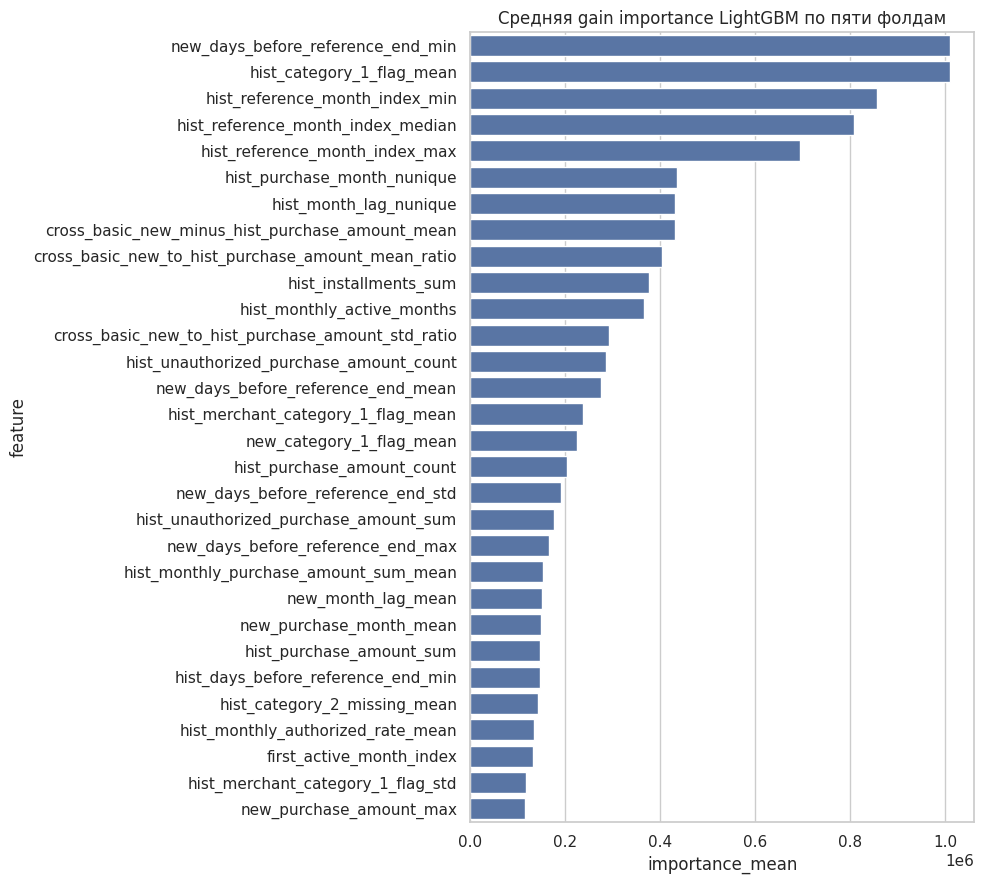

In [58]:
lgb_importance = tuned_lgb["importance"]

if lgb_importance is not None:
    display(lgb_importance.head(30))

    plt.figure(figsize=(10, 9))
    sns.barplot(
        data=lgb_importance.head(30),
        y="feature",
        x="importance_mean",
    )
    plt.title("Средняя gain importance LightGBM по пяти фолдам")
    plt.tight_layout()
    plt.show()

### 8.2. XGBoost: baseline → Optuna → bagging по seed

Сначала фиксирую понятную baseline-конфигурацию: стандартная регуляризация,
полная выборка строк и признаков, глубина 6. Затем Optuna отдельно подбирает
сложность деревьев, подвыборку и регуляризацию.


In [59]:
from xgboost import XGBRegressor

xgb_baseline_params = {
    "n_estimators": 5_000,
    "learning_rate": 0.03,
    "max_depth": 6,
    "min_child_weight": 1.0,
    "subsample": 1.0,
    "colsample_bytree": 1.0,
    "reg_alpha": 0.0,
    "reg_lambda": 1.0,
    "objective": "reg:squarederror",
    "eval_metric": "rmse",
    "random_state": SEED,
    "n_jobs": -1,
    "early_stopping_rounds": 200,
    **XGBOOST_GPU_PARAMS,
}

xgb_baseline = run_regression_cv(
    name="xgboost_baseline",
    model_factory=lambda fold_number: XGBRegressor(
        **xgb_baseline_params,
    ),
    X=X_main,
    X_test=X_test_main,
    fit_kwargs_builder=lambda model, X_train, y_train, X_valid, y_valid: {
        "eval_set": [(X_valid, y_valid)],
        "verbose": False,
    },
)

print("XGBoost baseline OOF RMSE:", xgb_baseline["OOF_RMSE"])

/home/vmuser/miniconda3/lib/python3.13/site-packages/xgboost/core.py:569: UserWarning: [19:42:21] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


xgboost_baseline | fold 1/5 | RMSE=3.65925
xgboost_baseline | fold 2/5 | RMSE=3.66914
xgboost_baseline | fold 3/5 | RMSE=3.63198
xgboost_baseline | fold 4/5 | RMSE=3.64652
xgboost_baseline | fold 5/5 | RMSE=3.66420
XGBoost baseline OOF RMSE: 3.6542422771453857


In [60]:
def xgboost_objective(trial):
    params = {
        "n_estimators": 5_000,
        "learning_rate": trial.suggest_float(
            "learning_rate",
            0.01,
            0.06,
            log=True,
        ),
        "max_depth": trial.suggest_int(
            "max_depth",
            3,
            9,
        ),
        "min_child_weight": trial.suggest_float(
            "min_child_weight",
            1.0,
            150.0,
            log=True,
        ),
        "subsample": trial.suggest_float(
            "subsample",
            0.6,
            1.0,
        ),
        "colsample_bytree": trial.suggest_float(
            "colsample_bytree",
            0.45,
            1.0,
        ),
        "reg_alpha": trial.suggest_float(
            "reg_alpha",
            1e-4,
            20.0,
            log=True,
        ),
        "reg_lambda": trial.suggest_float(
            "reg_lambda",
            1e-3,
            40.0,
            log=True,
        ),
        "gamma": trial.suggest_float(
            "gamma",
            0.0,
            5.0,
        ),
        "objective": "reg:squarederror",
        "eval_metric": "rmse",
        "random_state": SEED,
        "n_jobs": -1,
        "early_stopping_rounds": 200,
        **XGBOOST_GPU_PARAMS,
    }

    scores = []
    for fold_number, (train_index, valid_index) in enumerate(tuning_folds):
        model = XGBRegressor(**params)
        model.fit(
            X_main.iloc[train_index],
            y.iloc[train_index],
            eval_set=[
                (
                    X_main.iloc[valid_index],
                    y.iloc[valid_index],
                )
            ],
            verbose=False,
        )
        prediction = model.predict(X_main.iloc[valid_index])
        scores.append(
            root_mean_squared_error(
                y.iloc[valid_index],
                prediction,
            )
        )

        trial.report(float(np.mean(scores)), fold_number)
        del model
        gc.collect()

        if trial.should_prune():
            raise optuna.TrialPruned()

    return float(np.mean(scores))

In [61]:
xgb_best_search_params, xgb_history, xgb_tuning_meta = run_optuna_search(
    study_name="xgboost",
    objective=xgboost_objective,
    n_trials=XGB_OPTUNA_TRIALS,
    direction="minimize",
)

xgb_best_params = {
    "n_estimators": 5_000,
    **xgb_best_search_params,
    "objective": "reg:squarederror",
    "eval_metric": "rmse",
    "n_jobs": -1,
    "early_stopping_rounds": 200,
    **XGBOOST_GPU_PARAMS,
}

display(pd.Series(xgb_best_params, name="value").to_frame())
display(pd.Series(xgb_tuning_meta, name="value").to_frame())
if not xgb_history.empty and "value" in xgb_history.columns:
    display(
        xgb_history.sort_values("value").head(10)
    )

tuned_xgb = run_regression_cv(
    name="xgboost_tuned",
    model_factory=lambda fold_number: XGBRegressor(
        **xgb_best_params,
        random_state=SEED,
    ),
    X=X_main,
    X_test=X_test_main,
    fit_kwargs_builder=lambda model, X_train, y_train, X_valid, y_valid: {
        "eval_set": [(X_valid, y_valid)],
        "verbose": False,
    },
)

print("Tuned XGBoost OOF RMSE:", tuned_xgb["OOF_RMSE"])

/tmp/ipykernel_567744/4109533618.py:14: ExperimentalWarning: Argument ``multivariate`` is an experimental feature. The interface can change in the future.
  sampler=optuna.samplers.TPESampler(
Best trial: 0. Best value: 3.6514:   2%|▏         | 1/60 [00:10<10:32, 10.72s/it]

xgboost: trial 1/60, value=3.651395, best=3.651395


Best trial: 0. Best value: 3.6514:   3%|▎         | 2/60 [00:18<08:31,  8.82s/it]

xgboost: trial 2/60, value=3.662801, best=3.651395


Best trial: 0. Best value: 3.6514:   5%|▌         | 3/60 [00:26<08:09,  8.58s/it]

...

xgboost: trial 60/60, value=3.645968, best=3.645331


,value
n_estimators,5000
learning_rate,0.013373
max_depth,7
min_child_weight,4.578602
subsample,0.718082
colsample_bytree,0.586611
reg_alpha,14.079062
reg_lambda,32.017371
gamma,2.229867
objective,reg:squarederror


,value
study_name,xgboost
direction,minimize
n_trials,60
best_value,3.645331
runtime_seconds,707.774849
main_feature_set,+monthly
feature_count,331
device,GPU


,number,value,datetime_start,datetime_complete,duration,params_colsample_bytree,params_gamma,params_learning_rate,params_max_depth,params_min_child_weight,params_reg_alpha,params_reg_lambda,params_subsample,state
41,41,3.645331,2026-08-10 19:50:17.356004,2026-08-10 19:50:29.784676,0 days 00:00:12.428672,0.586611,2.229867,0.013373,7,4.578602,14.079062,32.017371,0.718082,COMPLETE
51,51,3.645724,2026-08-10 19:52:09.685246,2026-08-10 19:52:23.313648,0 days 00:00:13.628402,0.672803,2.928242,0.010754,7,4.939597,4.735736,39.667420,0.693253,COMPLETE
59,59,3.645968,2026-08-10 19:54:07.959283,2026-08-10 19:54:20.665545,0 days 00:00:12.706262,0.527922,2.380956,0.010066,8,129.273528,0.001711,1.631751,0.691165,COMPLETE
42,42,3.646157,2026-08-10 19:50:29.837562,2026-08-10 19:50:44.077749,0 days 00:00:14.240187,0.584151,2.818188,0.010373,7,2.451600,6.266705,26.298966,0.812603,COMPLETE
44,44,3.646439,2026-08-10 19:50:56.508399,2026-08-10 19:51:08.823460,0 days 00:00:12.315061,0.463638,2.329706,0.011158,7,21.907675,19.725087,18.548469,0.781917,COMPLETE
46,46,3.646822,2026-08-10 19:51:20.542318,2026-08-10 19:51:30.601069,0 days 00:00:10.058751,0.500055,2.367722,0.017975,7,5.645553,16.677026,33.618568,0.659193,COMPLETE
23,23,3.647040,2026-08-10 19:46:50.847592,2026-08-10 19:47:03.073806,0 days 00:00:12.226214,0.607091,0.604101,0.013385,8,87.412892,0.014264,28.341376,0.700870,COMPLETE
30,30,3.647045,2026-08-10 19:48:15.365004,2026-08-10 19:48:26.715310,0 days 00:00:11.350306,0.701015,1.016866,0.011249,6,3.240770,7.666472,18.665696,0.716739,COMPLETE
17,17,3.647112,2026-08-10 19:45:42.977074,2026-08-10 19:45:54.646802,0 days 00:00:11.669728,0.608258,0.675347,0.012210,6,7.576794,0.811204,32.941603,0.782756,COMPLETE
45,45,3.647213,2026-08-10 19:51:08.874315,2026-08-10 19:51:20.493621,0 days 00:00:11.619306,0.473767,2.669544,0.013652,7,32.998105,16.602036,11.383319,0.822624,COMPLETE


xgboost_tuned | fold 1/5 | RMSE=3.64681
xgboost_tuned | fold 2/5 | RMSE=3.65620
xgboost_tuned | fold 3/5 | RMSE=3.60854
xgboost_tuned | fold 4/5 | RMSE=3.62929
xgboost_tuned | fold 5/5 | RMSE=3.66600
Tuned XGBoost OOF RMSE: 3.6414246559143066


После настройки параметры фиксируются. Для bagging используются три заранее выбранных seed.
Они не отбираются по качеству: усредняются все три запуска.


In [62]:
XGB_BAGGING_SEEDS = [42, 17, 2026]

xgb_seed_results = [tuned_xgb]
xgb_seed_labels = [42]

for seed in XGB_BAGGING_SEEDS[1:]:
    result = run_regression_cv(
        name=f"xgboost_tuned_seed_{seed}",
        model_factory=lambda fold_number, seed=seed: XGBRegressor(
            **xgb_best_params,
            random_state=seed,
        ),
        X=X_main,
        X_test=X_test_main,
        fit_kwargs_builder=lambda model, X_train, y_train, X_valid, y_valid: {
            "eval_set": [(X_valid, y_valid)],
            "verbose": False,
        },
    )
    xgb_seed_results.append(result)
    xgb_seed_labels.append(seed)

xgb_bag_oof = np.mean(
    [
        result["oof"]
        for result in xgb_seed_results
    ],
    axis=0,
).astype("float32")
xgb_bag_test = np.mean(
    [
        result["test"]
        for result in xgb_seed_results
    ],
    axis=0,
).astype("float32")
xgb_bag_fold_scores = (
    fold_scores_from_prediction(
        xgb_bag_oof
    )
)
xgb_bag_score = root_mean_squared_error(
    y,
    xgb_bag_oof,
)

seed_table = pd.DataFrame(
    {
        "seed": xgb_seed_labels + ["mean"],
        "OOF_RMSE": [
            result["OOF_RMSE"]
            for result in xgb_seed_results
        ] + [xgb_bag_score],
    }
)
display(seed_table)

xgboost_tuned_seed_17 | fold 1/5 | RMSE=3.64651
xgboost_tuned_seed_17 | fold 2/5 | RMSE=3.65687
xgboost_tuned_seed_17 | fold 3/5 | RMSE=3.60804
xgboost_tuned_seed_17 | fold 4/5 | RMSE=3.62869
xgboost_tuned_seed_17 | fold 5/5 | RMSE=3.66355
xgboost_tuned_seed_2026 | fold 1/5 | RMSE=3.64456
xgboost_tuned_seed_2026 | fold 2/5 | RMSE=3.65640
xgboost_tuned_seed_2026 | fold 3/5 | RMSE=3.60580
xgboost_tuned_seed_2026 | fold 4/5 | RMSE=3.62694
xgboost_tuned_seed_2026 | fold 5/5 | RMSE=3.66635


,seed,OOF_RMSE
0,42,3.641425
1,17,3.640787
2,2026,3.640076
3,mean,3.639460


### 8.3. CatBoost на GPU

CatBoost получает исходные категориальные признаки без one-hot encoding.
Baseline, каждый trial Optuna и финальная пятифолдная модель обучаются
с `task_type="GPU"` на устройстве `0`.

GPU-версия CatBoost недетерминирована на уровне порядка операций с плавающей
точкой, поэтому повторный запуск может дать немного другие последние знаки RMSE.

In [63]:
from catboost import CatBoostRegressor

cat_feature_columns = [
    column
    for column in TREE_CATEGORICAL_COLUMNS
    if column in main_columns
]

X_cat_main = (
    full_train_features[main_columns]
    .replace([np.inf, -np.inf], np.nan)
    .reset_index(drop=True)
)
X_cat_test = (
    full_test_features[main_columns]
    .replace([np.inf, -np.inf], np.nan)
    .reset_index(drop=True)
)

cat_all_missing = [
    column
    for column in X_cat_main.columns
    if X_cat_main[column].isna().all()
]
X_cat_main = X_cat_main.drop(
    columns=cat_all_missing
)
X_cat_test = X_cat_test.drop(
    columns=cat_all_missing
)

cat_feature_columns = [
    column
    for column in cat_feature_columns
    if column in X_cat_main.columns
]
cat_numeric_columns = [
    column
    for column in X_cat_main.columns
    if column not in cat_feature_columns
]

for frame in [X_cat_main, X_cat_test]:
    for column in cat_feature_columns:
        frame[column] = (
            frame[column]
            .astype("Int64")
            .astype("string")
            .fillna("__MISSING__")
            .astype(str)
        )
    frame[cat_numeric_columns] = (
        frame[cat_numeric_columns]
        .astype("float32")
    )

assert list(X_cat_main.columns) == list(
    X_cat_test.columns
)

cat_baseline_params = {
    "iterations": 5_000,
    "learning_rate": 0.03,
    "depth": 6,
    "l2_leaf_reg": 3.0,
    "random_strength": 1.0,
    "bootstrap_type": "Bayesian",
    "bagging_temperature": 1.0,
    "loss_function": "RMSE",
    "random_seed": SEED,
    "verbose": False,
    "allow_writing_files": False,
    **CATBOOST_GPU_PARAMS,
}

In [64]:
cat_baseline = run_regression_cv(
    name="catboost_baseline",
    model_factory=lambda fold_number: CatBoostRegressor(
        **cat_baseline_params,
    ),
    X=X_cat_main,
    X_test=X_cat_test,
    fit_kwargs_builder=lambda model, X_train, y_train, X_valid, y_valid: {
        "cat_features": cat_feature_columns,
        "eval_set": (X_valid, y_valid),
        "early_stopping_rounds": 250,
        "verbose": False,
    },
)

print("CatBoost baseline OOF RMSE:", cat_baseline["OOF_RMSE"])

catboost_baseline | fold 1/5 | RMSE=3.65618
catboost_baseline | fold 2/5 | RMSE=3.65936
catboost_baseline | fold 3/5 | RMSE=3.62559
catboost_baseline | fold 4/5 | RMSE=3.64124
catboost_baseline | fold 5/5 | RMSE=3.67098
CatBoost baseline OOF RMSE: 3.650705337524414


In [65]:
def catboost_objective(trial):
    params = {
        "iterations": 5_000,
        "learning_rate": trial.suggest_float(
            "learning_rate",
            0.01,
            0.08,
            log=True,
        ),
        "depth": trial.suggest_int(
            "depth",
            5,
            10,
        ),
        "l2_leaf_reg": trial.suggest_float(
            "l2_leaf_reg",
            1.0,
            40.0,
            log=True,
        ),
        "random_strength": trial.suggest_float(
            "random_strength",
            0.0,
            5.0,
        ),
        "bootstrap_type": "Bayesian",
        "bagging_temperature": trial.suggest_float(
            "bagging_temperature",
            0.0,
            5.0,
        ),
        "loss_function": "RMSE",
        "random_seed": SEED,
        "verbose": False,
        "allow_writing_files": False,
        **CATBOOST_GPU_PARAMS,
    }

    scores = []
    for fold_number, (train_index, valid_index) in enumerate(tuning_folds):
        model = CatBoostRegressor(**params)
        model.fit(
            X_cat_main.iloc[train_index],
            y.iloc[train_index],
            cat_features=cat_feature_columns,
            eval_set=(
                X_cat_main.iloc[valid_index],
                y.iloc[valid_index],
            ),
            early_stopping_rounds=250,
            verbose=False,
        )
        prediction = model.predict(
            X_cat_main.iloc[valid_index]
        )
        scores.append(
            root_mean_squared_error(
                y.iloc[valid_index],
                prediction,
            )
        )

        trial.report(float(np.mean(scores)), fold_number)
        del model
        gc.collect()

        if trial.should_prune():
            raise optuna.TrialPruned()

    return float(np.mean(scores))

In [66]:
cat_best_search_params, cat_history, cat_tuning_meta = run_optuna_search(
    study_name="catboost",
    objective=catboost_objective,
    n_trials=CAT_OPTUNA_TRIALS,
    direction="minimize",
)

cat_best_params = {
    "iterations": 5_000,
    **cat_best_search_params,
    "bootstrap_type": "Bayesian",
    "loss_function": "RMSE",
    "verbose": False,
    "allow_writing_files": False,
    **CATBOOST_GPU_PARAMS,
}

display(pd.Series(cat_best_params, name="value").to_frame())
display(pd.Series(cat_tuning_meta, name="value").to_frame())
if not cat_history.empty and "value" in cat_history.columns:
    display(
        cat_history.sort_values("value").head(10)
    )

tuned_cat = run_regression_cv(
    name="catboost_tuned",
    model_factory=lambda fold_number: CatBoostRegressor(
        **cat_best_params,
        random_seed=SEED,
    ),
    X=X_cat_main,
    X_test=X_cat_test,
    fit_kwargs_builder=lambda model, X_train, y_train, X_valid, y_valid: {
        "cat_features": cat_feature_columns,
        "eval_set": (X_valid, y_valid),
        "early_stopping_rounds": 250,
        "verbose": False,
    },
)

print("Tuned CatBoost OOF RMSE:", tuned_cat["OOF_RMSE"])

/tmp/ipykernel_567744/4109533618.py:14: ExperimentalWarning: Argument ``multivariate`` is an experimental feature. The interface can change in the future.
  sampler=optuna.samplers.TPESampler(
Best trial: 0. Best value: 3.65213:   2%|▎         | 1/40 [02:37<1:42:17, 157.36s/it]

catboost: trial 1/40, value=3.652127, best=3.652127


Best trial: 0. Best value: 3.65213:   5%|▌         | 2/40 [04:19<1:19:01, 124.78s/it]

catboost: trial 2/40, value=3.689722, best=3.652127


Best trial: 0. Best value: 3.65213:   8%|▊         | 3/40 [09:47<2:14:05, 217.44s/it]

...

catboost: trial 40/40, value=3.650115, best=3.649185


,value
iterations,5000
learning_rate,0.010198
depth,9
l2_leaf_reg,3.026235
random_strength,1.292707
bagging_temperature,0.299364
bootstrap_type,Bayesian
loss_function,RMSE
verbose,False
allow_writing_files,False


,value
study_name,catboost
direction,minimize
n_trials,40
best_value,3.649185
runtime_seconds,5438.718758
main_feature_set,+monthly
feature_count,331
device,GPU


,number,value,datetime_start,datetime_complete,duration,params_bagging_temperature,params_depth,params_l2_leaf_reg,params_learning_rate,params_random_strength,state
36,36,3.649185,2026-08-10 21:15:43.940765,2026-08-10 21:18:21.037888,0 days 00:02:37.097123,0.299364,9,3.026235,0.010198,1.292707,COMPLETE
38,38,3.649385,2026-08-10 21:22:31.288046,2026-08-10 21:26:04.428099,0 days 00:03:33.140053,0.634567,10,2.814657,0.010090,1.077032,COMPLETE
39,39,3.650115,2026-08-10 21:26:04.481288,2026-08-10 21:27:49.054222,0 days 00:01:44.572934,0.319392,9,1.588669,0.014348,1.458387,COMPLETE
22,22,3.651058,2026-08-10 20:48:34.542495,2026-08-10 20:50:20.730587,0 days 00:01:46.188092,0.748279,8,1.156582,0.012420,1.722743,COMPLETE
23,23,3.651310,2026-08-10 20:50:20.783433,2026-08-10 20:52:39.829714,0 days 00:02:19.046281,0.863936,9,1.481112,0.011325,1.561344,COMPLETE
32,32,3.651424,2026-08-10 21:04:56.558214,2026-08-10 21:08:06.479660,0 days 00:03:09.921446,0.963815,10,2.684354,0.010919,0.749911,COMPLETE
24,24,3.651776,2026-08-10 20:52:39.895705,2026-08-10 20:54:11.834284,0 days 00:01:31.938579,0.169140,8,2.503423,0.014500,0.502122,COMPLETE
21,21,3.651853,2026-08-10 20:46:23.838882,2026-08-10 20:48:34.488349,0 days 00:02:10.649467,0.856358,8,3.642905,0.011202,1.213240,COMPLETE
0,0,3.652127,2026-08-10 19:57:10.388841,2026-08-10 19:59:47.689626,0 days 00:02:37.300785,0.780093,10,14.883265,0.021789,2.993292,COMPLETE
12,12,3.652187,2026-08-10 20:22:35.296626,2026-08-10 20:26:54.858426,0 days 00:04:19.561800,0.110738,9,27.983249,0.010388,3.730087,COMPLETE


catboost_tuned | fold 1/5 | RMSE=3.65043
catboost_tuned | fold 2/5 | RMSE=3.65842
catboost_tuned | fold 3/5 | RMSE=3.61389
catboost_tuned | fold 4/5 | RMSE=3.63650
catboost_tuned | fold 5/5 | RMSE=3.66640
Tuned CatBoost OOF RMSE: 3.6451733112335205


Сравниваю baseline и настроенные варианты каждой модели.


In [67]:
tuning_comparison = pd.DataFrame(
    {
        "model": [
            "LightGBM baseline on selected features",
            "LightGBM tuned",
            "XGBoost baseline",
            "XGBoost tuned",
            "XGBoost tuned seed bagging",
            "CatBoost baseline",
            "CatBoost tuned",
        ],
        "OOF_RMSE": [
            lgb_baseline_main["OOF_RMSE"],
            tuned_lgb["OOF_RMSE"],
            xgb_baseline["OOF_RMSE"],
            tuned_xgb["OOF_RMSE"],
            xgb_bag_score,
            cat_baseline["OOF_RMSE"],
            tuned_cat["OOF_RMSE"],
        ],
    }
)
display(tuning_comparison)

,model,OOF_RMSE
0,LightGBM baseline on selected features,3.684583
1,LightGBM tuned,3.657249
2,XGBoost baseline,3.654242
3,XGBoost tuned,3.641425
4,XGBoost tuned seed bagging,3.639460
5,CatBoost baseline,3.650705
6,CatBoost tuned,3.645173


## 9. Дополнительные гипотезы

### 9.1. Fold-safe target encoding

Проверяю только небольшое число интерпретируемых групп:

- комбинация `feature_1–3`;
- месяц первой активности;
- совместная комбинация.

Сглаживание не фиксируется заранее. На отдельной трёхфолдной схеме
сравниваются несколько значений и несколько наборов групп.


In [68]:
def make_target_encoding_groups(frame: pd.DataFrame) -> pd.DataFrame:
    active = pd.to_datetime(
        frame["first_active_month"],
        format="%Y-%m",
        errors="coerce",
    )
    f1 = frame["feature_1"].astype("Int64").astype(str)
    f2 = frame["feature_2"].astype("Int64").astype(str)
    f3 = frame["feature_3"].astype("Int64").astype(str)
    active_period = (
        active.dt.year.astype("Int64").astype(str)
        + "_"
        + active.dt.month.astype("Int64").astype(str)
    )

    return pd.DataFrame(
        {
            "f123": f1 + "_" + f2 + "_" + f3,
            "active": active_period,
            "f123_active": (
                f1 + "_" + f2 + "_" + f3 + "_" + active_period
            ),
        }
    )

te_groups_train = make_target_encoding_groups(train)
te_groups_test = make_target_encoding_groups(test)

te_group_audit = []
for column in te_groups_train:
    counts = te_groups_train[column].value_counts()
    te_group_audit.append(
        {
            "group": column,
            "unique_train": counts.size,
            "median_group_size": counts.median(),
            "groups_size_1": int((counts == 1).sum()),
            "groups_size_lt_10": int((counts < 10).sum()),
            "unknown_test_rate": float(
                (~te_groups_test[column].isin(counts.index)).mean()
            ),
        }
    )
display(pd.DataFrame(te_group_audit))

,group,unique_train,median_group_size,groups_size_1,groups_size_lt_10,unknown_test_rate
0,f123,14,12695.5,0,0,0.000000
1,active,75,481.0,1,4,0.000016
2,f123_active,495,213.0,23,65,0.000162


In [69]:
def fit_smooth_target_encoding(
    train_key,
    train_target,
    apply_key,
    smoothing,
):
    global_mean = float(np.mean(train_target))
    statistics = (
        pd.DataFrame(
            {
                "key": np.asarray(train_key),
                "target": np.asarray(train_target),
            }
        )
        .groupby("key")["target"]
        .agg(["sum", "count"])
    )

    encoding = (
        statistics["sum"] + smoothing * global_mean
    ) / (
        statistics["count"] + smoothing
    )

    return (
        pd.Series(np.asarray(apply_key))
        .map(encoding)
        .fillna(global_mean)
        .to_numpy("float32")
    )

Для обучающей части внешнего фолда target encoding тоже строится out-of-fold
по четырём внутренним фолдам. Так каждая строка получает среднее,
рассчитанное без её собственного target.

In [70]:
def build_fold_safe_te_matrices(
    outer_train_index,
    outer_valid_index,
    group_names,
    smoothing,
    X_base,
    X_test_base,
    inner_seed,
):
    X_outer_train = X_base.iloc[outer_train_index].copy()
    X_outer_valid = X_base.iloc[outer_valid_index].copy()
    X_outer_test = X_test_base.copy()

    groups_outer_train = (
        te_groups_train
        .iloc[outer_train_index]
        .reset_index(drop=True)
    )
    target_outer_train = (
        y.iloc[outer_train_index]
        .reset_index(drop=True)
    )

    inner_splitter = KFold(
        n_splits=4,
        shuffle=True,
        random_state=inner_seed,
    )

    for group_name in group_names:
        encoded_outer_train = np.zeros(
            len(outer_train_index),
            dtype="float32",
        )

        for inner_train, inner_valid in inner_splitter.split(
            groups_outer_train
        ):
            encoded_outer_train[inner_valid] = (
                fit_smooth_target_encoding(
                    groups_outer_train.iloc[inner_train][group_name],
                    target_outer_train.iloc[inner_train],
                    groups_outer_train.iloc[inner_valid][group_name],
                    smoothing=smoothing,
                )
            )

        X_outer_train[f"te_{group_name}"] = encoded_outer_train
        X_outer_valid[f"te_{group_name}"] = (
            fit_smooth_target_encoding(
                groups_outer_train[group_name],
                target_outer_train,
                te_groups_train.iloc[outer_valid_index][group_name],
                smoothing=smoothing,
            )
        )
        X_outer_test[f"te_{group_name}"] = (
            fit_smooth_target_encoding(
                groups_outer_train[group_name],
                target_outer_train,
                te_groups_test[group_name],
                smoothing=smoothing,
            )
        )

    return X_outer_train, X_outer_valid, X_outer_test

Сравниваю пять значений сглаживания и три набора групп.
Каждый вариант оценивается на одной и той же трёхфолдной схеме.

In [71]:
TE_SMOOTHING_GRID = [
    10.0,
    30.0,
    80.0,
    150.0,
    300.0,
]
TE_GROUP_SETS = {
    "f123": ["f123"],
    "f123+active": ["f123", "active"],
    "all_groups": [
        "f123",
        "active",
        "f123_active",
    ],
}

te_search_table = pd.DataFrame(
    columns=[
        "group_set",
        "smoothing",
        "mean_RMSE",
        "std_RMSE",
    ]
)

In [72]:
for group_set_name, group_names in TE_GROUP_SETS.items():
    for smoothing in TE_SMOOTHING_GRID:
        candidate_scores = []

        for fold_number, (
            train_index,
            valid_index,
        ) in enumerate(tuning_folds, start=1):
            (
                X_te_train,
                X_te_valid,
                _,
            ) = build_fold_safe_te_matrices(
                train_index,
                valid_index,
                group_names=group_names,
                smoothing=smoothing,
                X_base=X_main,
                X_test_base=X_test_main,
                inner_seed=SEED + 1_000 + fold_number,
            )

            model = XGBRegressor(
                **xgb_best_params,
                random_state=SEED,
            )
            model.fit(
                X_te_train,
                y.iloc[train_index],
                eval_set=[
                    (
                        X_te_valid,
                        y.iloc[valid_index],
                    )
                ],
                verbose=False,
            )
            prediction = model.predict(X_te_valid)
            candidate_scores.append(
                root_mean_squared_error(
                    y.iloc[valid_index],
                    prediction,
                )
            )

            del model
            gc.collect()

        candidate_row = pd.DataFrame(
            [
                {
                    "group_set": group_set_name,
                    "smoothing": smoothing,
                    "mean_RMSE": float(np.mean(candidate_scores)),
                    "std_RMSE": float(
                        np.std(candidate_scores, ddof=1)
                    ),
                }
            ]
        )
        te_search_table = pd.concat(
            [te_search_table, candidate_row],
            ignore_index=True,
        )

display(
    te_search_table.sort_values("mean_RMSE").head(15)
)

,group_set,smoothing,mean_RMSE,std_RMSE
0,f123,10.0,3.644866,0.008796
8,f123+active,150.0,3.644985,0.009256
1,f123,30.0,3.645025,0.008308
6,f123+active,30.0,3.645035,0.009204
4,f123,300.0,3.645116,0.008678
10,all_groups,10.0,3.645195,0.008598
2,f123,80.0,3.645196,0.008904
3,f123,150.0,3.645279,0.008638
5,f123+active,10.0,3.645297,0.009070
9,f123+active,300.0,3.645352,0.008694


In [73]:
best_te_row = (
    te_search_table
    .sort_values(["mean_RMSE", "std_RMSE"])
    .iloc[0]
)
BEST_TE_GROUP_SET = best_te_row["group_set"]
BEST_TE_GROUPS = TE_GROUP_SETS[BEST_TE_GROUP_SET]
BEST_TE_SMOOTHING = float(best_te_row["smoothing"])

print("Выбранный набор групп:", BEST_TE_GROUP_SET)
print("Выбранное сглаживание:", BEST_TE_SMOOTHING)

Выбранный набор групп: f123
Выбранное сглаживание: 10.0


После выбора параметров получаю итоговые пятифолдные OOF- и test-прогнозы.


In [74]:
te_oof = np.zeros(len(y), dtype="float32")
te_test = np.zeros(len(X_test_main), dtype="float32")
te_fold_scores = []
te_start_time = time.perf_counter()

for fold_number, (
    train_index,
    valid_index,
) in enumerate(primary_folds, start=1):
    (
        X_te_train,
        X_te_valid,
        X_te_test,
    ) = build_fold_safe_te_matrices(
        train_index,
        valid_index,
        group_names=BEST_TE_GROUPS,
        smoothing=BEST_TE_SMOOTHING,
        X_base=X_main,
        X_test_base=X_test_main,
        inner_seed=SEED + 2_000 + fold_number,
    )

    model = XGBRegressor(
        **xgb_best_params,
        random_state=SEED,
    )
    model.fit(
        X_te_train,
        y.iloc[train_index],
        eval_set=[
            (
                X_te_valid,
                y.iloc[valid_index],
            )
        ],
        verbose=False,
    )

    te_oof[valid_index] = model.predict(X_te_valid)
    te_test += model.predict(X_te_test) / len(primary_folds)

    score = root_mean_squared_error(
        y.iloc[valid_index],
        te_oof[valid_index],
    )
    te_fold_scores.append(float(score))

    del model
    gc.collect()
    print(
        f"XGBoost + TE | fold {fold_number}/{len(primary_folds)} "
        f"| RMSE={score:.5f}"
    )

te_runtime = time.perf_counter() - te_start_time
te_score = root_mean_squared_error(y, te_oof)

display(
    pd.DataFrame(
        {
            "model": ["Tuned XGBoost", "Tuned XGBoost + TE"],
            "OOF_RMSE": [
                tuned_xgb["OOF_RMSE"],
                te_score,
            ],
        }
    )
)

XGBoost + TE | fold 1/5 | RMSE=3.64613
XGBoost + TE | fold 2/5 | RMSE=3.65531
XGBoost + TE | fold 3/5 | RMSE=3.60937
XGBoost + TE | fold 4/5 | RMSE=3.62938
XGBoost + TE | fold 5/5 | RMSE=3.66439


,model,OOF_RMSE
0,Tuned XGBoost,3.641425
1,Tuned XGBoost + TE,3.640968


### 9.2. Отдельная модель экстремального сегмента

Классификатор не заменяет регрессию. Он нужен только для проверки,
может ли вероятность экстремального target улучшить итоговый RMSE.

Параметры LightGBMClassifier подбираются по PR-AUC, поскольку положительный класс редкий.
ROC-AUC выводится только как дополнительная характеристика.


Сначала оцениваю консервативный baseline-классификатор.
Это показывает, дал ли последующий Optuna-поиск реальное улучшение PR-AUC.


In [75]:
from lightgbm import LGBMClassifier

extreme_target = (
    extreme_indicator.to_numpy()
)

outlier_baseline_params = {
    "n_estimators": 3_000,
    "learning_rate": 0.03,
    "num_leaves": 31,
    "random_state": SEED,
    "n_jobs": -1,
    "verbosity": -1,
    "subsample_freq": 1,
    **LIGHTGBM_GPU_PARAMS,
}

outlier_baseline_oof = np.zeros(
    len(y),
    dtype="float32",
)

for fold_number, (
    train_index,
    valid_index,
) in enumerate(primary_folds, start=1):
    positives = extreme_target[
        train_index
    ].sum()
    negatives = (
        len(train_index) - positives
    )

    baseline_classifier = (
        LGBMClassifier(
            **outlier_baseline_params,
            scale_pos_weight=(
                negatives
                / max(positives, 1)
            ),
        )
    )
    baseline_classifier.fit(
        X_main.iloc[train_index],
        extreme_target[train_index],
        eval_set=[
            (
                X_main.iloc[valid_index],
                extreme_target[valid_index],
            )
        ],
        callbacks=[
            lgb.early_stopping(
                180,
                verbose=False,
            )
        ],
    )

    outlier_baseline_oof[
        valid_index
    ] = baseline_classifier.predict_proba(
        X_main.iloc[valid_index]
    )[:, 1]

outlier_baseline_pr_auc = (
    average_precision_score(
        extreme_target,
        outlier_baseline_oof,
    )
)
outlier_baseline_roc_auc = (
    roc_auc_score(
        extreme_target,
        outlier_baseline_oof,
    )
)

print(
    "Baseline PR-AUC:",
    outlier_baseline_pr_auc,
)
print(
    "Baseline ROC-AUC:",
    outlier_baseline_roc_auc,
)

Baseline PR-AUC: 0.011631573839468522
Baseline ROC-AUC: 0.5189465855985061


Теперь подбираю сложность деревьев, подвыборку и регуляризацию
на отдельной трёхфолдной схеме.


In [76]:
def outlier_classifier_objective(trial):
    max_depth = trial.suggest_int("max_depth", 3, 9)
    max_leaves = min(64, 2 ** max_depth)

    params = {
        "n_estimators": 4_000,
        "learning_rate": trial.suggest_float(
            "learning_rate",
            0.01,
            0.06,
            log=True,
        ),
        "max_depth": max_depth,
        "num_leaves": trial.suggest_int(
            "num_leaves",
            8,
            max_leaves,
        ),
        "min_child_samples": trial.suggest_int(
            "min_child_samples",
            20,
            200,
        ),
        "subsample": trial.suggest_float(
            "subsample",
            0.65,
            1.0,
        ),
        "subsample_freq": 1,
        "colsample_bytree": trial.suggest_float(
            "colsample_bytree",
            0.5,
            1.0,
        ),
        "reg_alpha": trial.suggest_float(
            "reg_alpha",
            1e-4,
            20.0,
            log=True,
        ),
        "reg_lambda": trial.suggest_float(
            "reg_lambda",
            1e-4,
            30.0,
            log=True,
        ),
        "random_state": SEED,
        "n_jobs": -1,
        "verbosity": -1,
        **LIGHTGBM_GPU_PARAMS,
    }

    scores = []
    for fold_number, (train_index, valid_index) in enumerate(tuning_folds):
        positives = extreme_target[train_index].sum()
        negatives = len(train_index) - positives

        model = LGBMClassifier(
            **params,
            scale_pos_weight=negatives / max(positives, 1),
        )
        model.fit(
            X_main.iloc[train_index],
            extreme_target[train_index],
            eval_set=[
                (
                    X_main.iloc[valid_index],
                    extreme_target[valid_index],
                )
            ],
            callbacks=[
                lgb.early_stopping(180, verbose=False)
            ],
        )

        probability = model.predict_proba(
            X_main.iloc[valid_index]
        )[:, 1]
        scores.append(
            average_precision_score(
                extreme_target[valid_index],
                probability,
            )
        )

        trial.report(float(np.mean(scores)), fold_number)
        del model
        gc.collect()

        if trial.should_prune():
            raise optuna.TrialPruned()

    return float(np.mean(scores))

In [77]:
outlier_best_search_params, outlier_history, outlier_tuning_meta = (
    run_optuna_search(
        study_name="outlier_classifier",
        objective=outlier_classifier_objective,
        n_trials=OUTLIER_OPTUNA_TRIALS,
        direction="maximize",
    )
)

outlier_best_params = {
    "n_estimators": 4_000,
    **outlier_best_search_params,
    "subsample_freq": 1,
    "random_state": SEED,
    "n_jobs": -1,
    "verbosity": -1,
    **LIGHTGBM_GPU_PARAMS,
}

display(pd.Series(outlier_best_params, name="value").to_frame())
display(pd.Series(outlier_tuning_meta, name="value").to_frame())
if (
    not outlier_history.empty
    and "value" in outlier_history.columns
):
    display(
        outlier_history.sort_values(
            "value",
            ascending=False,
        ).head(10)
    )

/tmp/ipykernel_567744/4109533618.py:14: ExperimentalWarning: Argument ``multivariate`` is an experimental feature. The interface can change in the future.
  sampler=optuna.samplers.TPESampler(
Best trial: 0. Best value: 0.0109302:   3%|▎         | 1/30 [00:04<01:56,  4.02s/it]

outlier_classifier: trial 1/30, value=0.010930, best=0.010930


Best trial: 0. Best value: 0.0109302:   7%|▋         | 2/30 [00:07<01:50,  3.96s/it]

outlier_classifier: trial 2/30, value=0.010930, best=0.010930


Best trial: 0. Best value: 0.0109302:  10%|█         | 3/30 [00:11<01:46,  3.95s/it]

...

Best trial: 0. Best value: 0.0109302: 100%|██████████| 30/30 [01:58<00:00,  3.95s/it]

outlier_classifier: trial 30/30, value=0.010930, best=0.010930


,value
n_estimators,4000
max_depth,5
learning_rate,0.054929
num_leaves,26
min_child_samples,128
subsample,0.704607
colsample_bytree,0.577997
reg_alpha,0.000203
reg_lambda,5.548196
subsample_freq,1


,value
study_name,outlier_classifier
direction,maximize
n_trials,30
best_value,0.01093
runtime_seconds,118.46401
main_feature_set,+monthly
feature_count,331
device,GPU


,number,value,datetime_start,datetime_complete,duration,params_colsample_bytree,params_learning_rate,params_max_depth,params_min_child_samples,params_num_leaves,params_reg_alpha,params_reg_lambda,params_subsample,state
0,0,0.01093,2026-08-10 21:36:00.932863,2026-08-10 21:36:04.894332,0 days 00:00:03.961469,0.577997,0.054929,5,128,26,0.000203,5.548196,0.704607,COMPLETE
1,1,0.01093,2026-08-10 21:36:04.954679,2026-08-10 21:36:08.815393,0 days 00:00:03.860714,0.606170,0.035562,7,195,9,0.000920,0.001010,0.941355,COMPLETE
2,2,0.01093,2026-08-10 21:36:08.873559,2026-08-10 21:36:12.765629,0 days 00:00:03.892070,0.569747,0.025606,5,72,18,0.003537,0.010153,0.864149,COMPLETE
3,3,0.01093,2026-08-10 21:36:12.820085,2026-08-10 21:36:16.738343,0 days 00:00:03.918258,0.523225,0.040831,6,113,19,0.166193,0.000859,0.857345,COMPLETE
4,4,0.01093,2026-08-10 21:36:16.795932,2026-08-10 21:36:20.708761,0 days 00:00:03.912829,0.652307,0.054749,3,194,8,0.000329,0.559277,0.932939,COMPLETE
5,5,0.01093,2026-08-10 21:36:20.766768,2026-08-10 21:36:24.714504,0 days 00:00:03.947736,0.629390,0.012444,6,26,36,0.325125,0.005097,0.968262,COMPLETE
6,6,0.01093,2026-08-10 21:36:24.771972,2026-08-10 21:36:28.713871,0 days 00:00:03.941899,0.969749,0.026633,6,195,18,5.539960,0.188265,0.921296,COMPLETE
7,7,0.01093,2026-08-10 21:36:28.774495,2026-08-10 21:36:32.655064,0 days 00:00:03.880569,0.694339,0.011718,9,28,19,0.002744,3.460157,0.763866,COMPLETE
8,8,0.01093,2026-08-10 21:36:32.709496,2026-08-10 21:36:36.626835,0 days 00:00:03.917339,0.537275,0.016543,5,45,21,17.041870,1.696986,0.930769,COMPLETE
9,9,0.01093,2026-08-10 21:36:36.680088,2026-08-10 21:36:40.555605,0 days 00:00:03.875517,0.885635,0.010099,4,147,15,0.000247,0.009191,0.905153,COMPLETE


In [78]:
outlier_oof = np.zeros(len(y), dtype="float32")
outlier_test = np.zeros(len(X_test_main), dtype="float32")
outlier_fold_pr_auc = []

for fold_number, (
    train_index,
    valid_index,
) in enumerate(primary_folds, start=1):
    positives = extreme_target[train_index].sum()
    negatives = len(train_index) - positives

    model = LGBMClassifier(
        **outlier_best_params,
        scale_pos_weight=negatives / max(positives, 1),
    )
    model.fit(
        X_main.iloc[train_index],
        extreme_target[train_index],
        eval_set=[
            (
                X_main.iloc[valid_index],
                extreme_target[valid_index],
            )
        ],
        callbacks=[
            lgb.early_stopping(200, verbose=False)
        ],
    )

    outlier_oof[valid_index] = model.predict_proba(
        X_main.iloc[valid_index]
    )[:, 1]
    outlier_test += (
        model.predict_proba(X_test_main)[:, 1]
        / len(primary_folds)
    )

    outlier_fold_pr_auc.append(
        average_precision_score(
            extreme_target[valid_index],
            outlier_oof[valid_index],
        )
    )

print(
    "OOF ROC-AUC:",
    roc_auc_score(extreme_target, outlier_oof),
)
print(
    "OOF PR-AUC:",
    average_precision_score(extreme_target, outlier_oof),
)
print(
    "PR-AUC по фолдам:",
    np.round(outlier_fold_pr_auc, 4),
)


outlier_tuned_pr_auc = average_precision_score(
    extreme_target,
    outlier_oof,
)
outlier_tuned_roc_auc = roc_auc_score(
    extreme_target,
    outlier_oof,
)

display(
    pd.DataFrame(
        {
            "classifier": [
                "baseline",
                "tuned",
            ],
            "OOF_PR_AUC": [
                outlier_baseline_pr_auc,
                outlier_tuned_pr_auc,
            ],
            "OOF_ROC_AUC": [
                outlier_baseline_roc_auc,
                outlier_tuned_roc_auc,
            ],
        }
    )
)

OOF ROC-AUC: 0.4997281377435433
OOF PR-AUC: 0.010924360901250457
PR-AUC по фолдам: [0.0109 0.0109 0.0109 0.0109 0.0109]


,classifier,OOF_PR_AUC,OOF_ROC_AUC
0,baseline,0.011632,0.518947
1,tuned,0.010924,0.499728


In [79]:
calibration_frame = pd.DataFrame(
    {
        "probability": outlier_oof,
        "extreme": extreme_target,
    }
)
calibration_frame["bin"] = pd.qcut(
    calibration_frame["probability"],
    10,
    duplicates="drop",
)

calibration_table = (
    calibration_frame
    .groupby("bin", observed=False)
    .agg(
        mean_probability=("probability", "mean"),
        observed_rate=("extreme", "mean"),
        cards=("extreme", "size"),
    )
)
display(calibration_table)

threshold_diagnostics = []
for threshold in np.quantile(
    outlier_oof,
    [0.80, 0.90, 0.95, 0.97, 0.99],
):
    matrix = confusion_matrix(
        extreme_target,
        outlier_oof >= threshold,
    )
    tn, fp, fn, tp = matrix.ravel()
    threshold_diagnostics.append(
        {
            "threshold": threshold,
            "cards_selected": int((outlier_oof >= threshold).sum()),
            "true_positive": int(tp),
            "false_positive": int(fp),
            "false_negative": int(fn),
        }
    )

display(pd.DataFrame(threshold_diagnostics))

,mean_probability,observed_rate,cards
bin,,,
"(0.010917, 0.010933]",0.01093,0.01093,201917


,threshold,cards_selected,true_positive,false_positive,false_negative
0,0.010933,121149,1323,119826,884
1,0.010933,121149,1323,119826,884
2,0.010933,121149,1323,119826,884
3,0.010933,121149,1323,119826,884
4,0.010933,121149,1323,119826,884


## 10. Сравнение одиночных моделей

Собираю результаты основных моделей в едином формате.
В таблице есть не только общий OOF RMSE, но и разброс фолдов и время обучения.


In [80]:
def custom_result_summary(
    name,
    oof,
    test_prediction,
    fold_scores,
    runtime_seconds=np.nan,
):
    return {
        "name": name,
        "oof": np.asarray(oof),
        "test": np.asarray(test_prediction),
        "fold_scores": list(fold_scores),
        "OOF_RMSE": float(root_mean_squared_error(y, oof)),
        "fold_mean_RMSE": float(np.mean(fold_scores)),
        "fold_std_RMSE": float(np.std(fold_scores, ddof=1)),
        "fold_min_RMSE": float(np.min(fold_scores)),
        "fold_max_RMSE": float(np.max(fold_scores)),
        "runtime_seconds": float(runtime_seconds),
    }

xgb_bag_result = custom_result_summary(
    "xgboost_seed_bagging",
    xgb_bag_oof,
    xgb_bag_test,
    xgb_bag_fold_scores,
    runtime_seconds=sum(
        result["runtime_seconds"]
        for result in xgb_seed_results
    ),
)
te_result = custom_result_summary(
    "xgboost_target_encoding",
    te_oof,
    te_test,
    te_fold_scores,
    runtime_seconds=te_runtime,
)

all_single_model_results = {
    "lightgbm_tuned": tuned_lgb,
    "xgboost_tuned": tuned_xgb,
    "xgboost_seed_bagging": xgb_bag_result,
    "catboost_tuned": tuned_cat,
    "xgboost_target_encoding": te_result,
}

single_model_table = pd.DataFrame(
    [
        {
            "model": name,
            "OOF_RMSE": result["OOF_RMSE"],
            "fold_mean_RMSE": result["fold_mean_RMSE"],
            "fold_std_RMSE": result["fold_std_RMSE"],
            "fold_min_RMSE": result["fold_min_RMSE"],
            "fold_max_RMSE": result["fold_max_RMSE"],
            "cv_runtime_minutes": result["runtime_seconds"] / 60,
        }
        for name, result in all_single_model_results.items()
    ]
).sort_values("OOF_RMSE")

display(single_model_table)

if xgb_bag_score < tuned_xgb["OOF_RMSE"]:
    XGB_ENSEMBLE_NAME = "xgboost_seed_bagging"
    xgb_ensemble_result = xgb_bag_result
else:
    XGB_ENSEMBLE_NAME = "xgboost_tuned"
    xgb_ensemble_result = tuned_xgb

single_model_results = {
    "lightgbm_tuned": tuned_lgb,
    XGB_ENSEMBLE_NAME: xgb_ensemble_result,
    "catboost_tuned": tuned_cat,
    "xgboost_target_encoding": te_result,
}

print(
    "XGBoost-кандидат для ансамбля:",
    XGB_ENSEMBLE_NAME,
)

,model,OOF_RMSE,fold_mean_RMSE,fold_std_RMSE,fold_min_RMSE,fold_max_RMSE,cv_runtime_minutes
2,xgboost_seed_bagging,3.639460,3.639400,0.023243,3.606002,3.664175,1.261147
4,xgboost_target_encoding,3.640968,3.640915,0.021872,3.609370,3.664390,0.438705
1,xgboost_tuned,3.641425,3.641367,0.022802,3.608543,3.665998,0.411817
3,catboost_tuned,3.645173,3.645126,0.020663,3.613885,3.666400,4.231059
0,lightgbm_tuned,3.657249,3.657206,0.019897,3.631317,3.678911,0.640941


XGBoost-кандидат для ансамбля: xgboost_seed_bagging


Корреляция остатков показывает разнообразие моделей.
Для ансамбля полезна не только самая точная модель, но и модель,
которая ошибается иначе.


,lightgbm_tuned,xgboost_seed_bagging,catboost_tuned,xgboost_target_encoding
lightgbm_tuned,1.0000,0.9961,0.9956,0.9957
xgboost_seed_bagging,0.9961,1.0000,0.9976,0.9995
catboost_tuned,0.9956,0.9976,1.0000,0.9972
xgboost_target_encoding,0.9957,0.9995,0.9972,1.0000


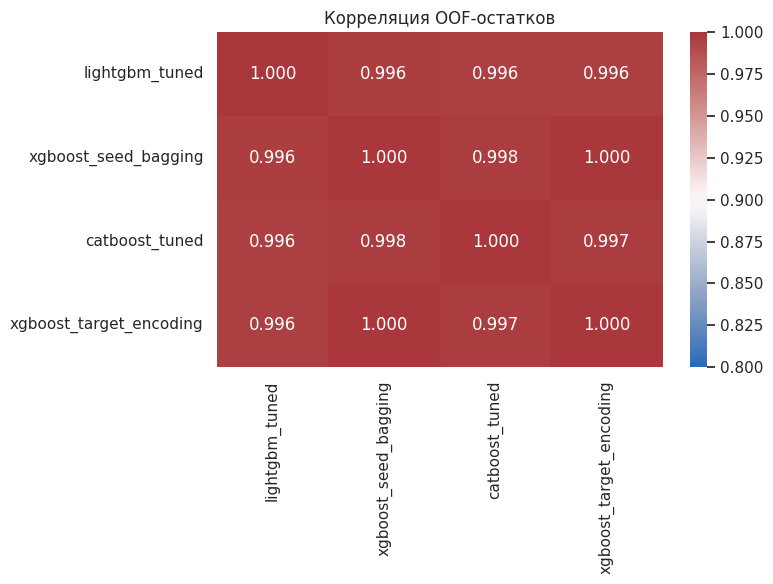

In [81]:
residual_correlation = pd.DataFrame(
    {
        name: y.to_numpy() - result["oof"]
        for name, result in single_model_results.items()
    }
).corr()

display(residual_correlation.round(4))

plt.figure(figsize=(8, 6))
sns.heatmap(
    residual_correlation,
    annot=True,
    fmt=".3f",
    cmap="vlag",
    vmin=0.8,
    vmax=1.0,
)
plt.title("Корреляция OOF-остатков")
plt.tight_layout()
plt.show()

## 11. Ансамбли

Использую стандартную практическую схему на OOF-прогнозах.
Каждая строка базовой OOF-матрицы получена моделью, не обученной на target этой строки.

Весовой blend и Ridge-метамодель дополнительно оцениваются по метафолдам.
Это снижает прямое переобучение метауровня, но не является полной nested CV
с повторным обучением всех базовых моделей внутри каждого метафолда.
Поэтому микроскопические улучшения интерпретируются осторожно.

### 11.1. Weighted blend


In [82]:
from scipy.optimize import minimize

base_oof = {
    name: result["oof"]
    for name, result in single_model_results.items()
}
base_test = {
    name: result["test"]
    for name, result in single_model_results.items()
}

def fit_nonnegative_blend_weights(
    target,
    prediction_matrix,
):
    initial = np.full(
        prediction_matrix.shape[1],
        1 / prediction_matrix.shape[1],
    )

    optimization = minimize(
        lambda weights: root_mean_squared_error(
            target,
            prediction_matrix @ weights,
        ),
        initial,
        method="SLSQP",
        bounds=[
            (0.0, 1.0)
            for _ in range(prediction_matrix.shape[1])
        ],
        constraints={
            "type": "eq",
            "fun": lambda weights: weights.sum() - 1.0,
        },
        options={
            "maxiter": 500,
            "ftol": 1e-10,
        },
    )

    if not optimization.success:
        raise RuntimeError(optimization.message)

    return optimization.x

In [83]:
model_names = list(base_oof)
oof_matrix = np.column_stack(
    [base_oof[name] for name in model_names]
)
test_matrix = np.column_stack(
    [base_test[name] for name in model_names]
)

blend_oof = np.zeros(len(y), dtype="float32")
blend_fold_weight_rows = []

for fold_number, (
    train_index,
    valid_index,
) in enumerate(primary_folds, start=1):
    weights = fit_nonnegative_blend_weights(
        y.iloc[train_index],
        oof_matrix[train_index],
    )
    blend_oof[valid_index] = (
        oof_matrix[valid_index] @ weights
    )

    blend_fold_weight_rows.append(
        {
            "fold": fold_number,
            **{
                name: float(weight)
                for name, weight in zip(model_names, weights)
            },
        }
    )

final_blend_weights_array = fit_nonnegative_blend_weights(
    y,
    oof_matrix,
)
blend_test = test_matrix @ final_blend_weights_array

blend_fold_scores = fold_scores_from_prediction(blend_oof)
blend_result = custom_result_summary(
    "weighted_blend",
    blend_oof,
    blend_test,
    blend_fold_scores,
)

display(pd.DataFrame(blend_fold_weight_rows))
display(
    pd.Series(
        final_blend_weights_array,
        index=model_names,
        name="final_weight",
    ).to_frame()
)
print("Weighted blend OOF RMSE:", blend_result["OOF_RMSE"])

,fold,lightgbm_tuned,xgboost_seed_bagging,catboost_tuned,xgboost_target_encoding
0,1,4.863982e-17,0.782761,0.172129,4.511068e-02
1,2,0.000000e+00,0.860732,0.139268,1.665335e-16
2,3,1.258521e-17,0.636717,0.195871,1.674122e-01
3,4,0.000000e+00,0.693715,0.229970,7.631456e-02
4,5,0.000000e+00,0.866894,0.133106,1.082467e-15


,final_weight
lightgbm_tuned,2.471669e-17
xgboost_seed_bagging,7.834118e-01
catboost_tuned,1.742358e-01
xgboost_target_encoding,4.235243e-02


Weighted blend OOF RMSE: 3.6393661499023438


### 11.2. Ridge stacking

Диапазон `alpha` покрывает слабую и сильную регуляризацию в логарифмическом масштабе.
Конкретное значение выбирается внутри каждого метафолда.

Коэффициенты ниже относятся к стандартизованным OOF-прогнозам, поэтому их масштаб нельзя напрямую трактовать как веса обычного среднего.


Метамодель Ridge обучается на нескольких столбцах OOF-прогнозов и занимает
считанные секунды, поэтому этот небольшой этап остаётся на CPU.


In [84]:
from sklearn.linear_model import RidgeCV
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

stack_oof = np.zeros(len(y), dtype="float32")
stack_fold_rows = []
stack_coefficient_rows = []

for fold_number, (
    train_index,
    valid_index,
) in enumerate(primary_folds, start=1):
    meta_model = make_pipeline(
        StandardScaler(),
        RidgeCV(alphas=np.logspace(-4, 4, 40)),
    )
    meta_model.fit(
        oof_matrix[train_index],
        y.iloc[train_index],
    )
    stack_oof[valid_index] = meta_model.predict(
        oof_matrix[valid_index]
    )

    ridge_model = meta_model.named_steps["ridgecv"]
    stack_fold_rows.append(
        {
            "fold": fold_number,
            "alpha": float(ridge_model.alpha_),
            "valid_RMSE": root_mean_squared_error(
                y.iloc[valid_index],
                stack_oof[valid_index],
            ),
        }
    )
    stack_coefficient_rows.append(
        {
            "fold": fold_number,
            **{
                name: float(coefficient)
                for name, coefficient in zip(
                    model_names,
                    ridge_model.coef_,
                )
            },
        }
    )

final_stack_model = make_pipeline(
    StandardScaler(),
    RidgeCV(alphas=np.logspace(-4, 4, 40)),
)
final_stack_model.fit(oof_matrix, y)
stack_test = final_stack_model.predict(test_matrix)

stack_fold_scores = fold_scores_from_prediction(stack_oof)
stack_result = custom_result_summary(
    "ridge_stacking",
    stack_oof,
    stack_test,
    stack_fold_scores,
)

display(pd.DataFrame(stack_fold_rows))
display(pd.DataFrame(stack_coefficient_rows))
print("Ridge stacking OOF RMSE:", stack_result["OOF_RMSE"])

,fold,alpha,valid_RMSE
0,1,228.546386,3.643881
1,2,142.510267,3.654455
2,3,587.801607,3.605473
3,4,366.524124,3.627562
4,5,142.510267,3.664697


,fold,lightgbm_tuned,xgboost_seed_bagging,catboost_tuned,xgboost_target_encoding
0,1,-0.100296,0.901423,0.300247,0.164862
1,2,-0.073846,1.054954,0.268307,0.019514
2,3,-0.065973,0.660111,0.310487,0.328122
3,4,-0.112307,0.748958,0.379051,0.240614
4,5,-0.078351,1.028989,0.278454,0.054959


Ridge stacking OOF RMSE: 3.6392736434936523


### 11.3. Проверка корректировки экстремального сегмента

Отдельный классификатор для карт с `target < -30` не дал полезного ранжирования: его OOF PR-AUC (`0.0109`) практически совпал с базовой долей экстремальных наблюдений, а ROC-AUC составил `0.4997`. Вероятности почти не различались, поэтому все квантили свелись к одному порогу `0.010933`.

Из-за сравнения `>=` этот порог выбрал 121 149 карт из 201 917, а в трёх внешних фолдах заменил по 40 383 предсказания. Корректировка заметно уменьшила ошибку на хвосте, но разрушила прогнозы для основного массива наблюдений. Эксперимент оставлен в ноутбуке как отрицательный результат и исключён из финального решения.

In [85]:
threshold_grid = np.unique(
    np.quantile(
        outlier_oof,
        [0.75, 0.80, 0.85, 0.90, 0.93, 0.95, 0.97, 0.99],
    )
)

extreme_values = y[extreme_indicator == 1]
replacement_grid = np.unique(
    np.concatenate(
        [
            np.quantile(
                extreme_values,
                [0.10, 0.25, 0.50, 0.75, 0.90],
            ),
            np.linspace(
                float(extreme_values.mean()),
                float(y.quantile(0.01)),
                6,
            ),
        ]
    )
)

print("Порогов вероятности:", len(threshold_grid))
print("Кандидатов замены:", len(replacement_grid))
display(
    pd.DataFrame(
        {
            "threshold_grid": pd.Series(threshold_grid),
            "replacement_grid": pd.Series(replacement_grid),
        }
    )
)

Порогов вероятности: 1
Кандидатов замены: 1


,threshold_grid,replacement_grid
0,0.010933,-33.21928


In [86]:
corrected_oof = np.zeros(len(y), dtype="float32")
correction_rows = []

for fold_number, (
    train_index,
    valid_index,
) in enumerate(primary_folds, start=1):
    best_train_score = np.inf
    best_parameters = None

    for threshold in threshold_grid:
        for replacement in replacement_grid:
            train_candidate = blend_oof[train_index].copy()
            selected_train = (
                outlier_oof[train_index] >= threshold
            )
            train_candidate[selected_train] = replacement

            denominator = float(
                np.sum(outlier_oof[train_index] ** 2)
            )
            alpha = 0.0
            if denominator > 0:
                alpha = max(
                    0.0,
                    float(
                        np.sum(
                            outlier_oof[train_index]
                            * (
                                train_candidate
                                - y.iloc[train_index].to_numpy()
                            )
                        )
                        / denominator
                    ),
                )

            train_adjusted = (
                train_candidate
                - alpha * outlier_oof[train_index]
            )
            train_score = root_mean_squared_error(
                y.iloc[train_index],
                train_adjusted,
            )

            if train_score < best_train_score:
                best_train_score = train_score
                best_parameters = (
                    float(threshold),
                    float(replacement),
                    float(alpha),
                )

    threshold, replacement, alpha = best_parameters

    valid_prediction = blend_oof[valid_index].copy()
    selected_valid = (
        outlier_oof[valid_index] >= threshold
    )
    valid_prediction[selected_valid] = replacement
    valid_prediction = (
        valid_prediction
        - alpha * outlier_oof[valid_index]
    )
    corrected_oof[valid_index] = valid_prediction

    correction_rows.append(
        {
            "fold": fold_number,
            "threshold": threshold,
            "replacement": replacement,
            "alpha": alpha,
            "valid_cards_changed": int(selected_valid.sum()),
            "valid_RMSE": root_mean_squared_error(
                y.iloc[valid_index],
                valid_prediction,
            ),
        }
    )

correction_table = pd.DataFrame(correction_rows)
display(correction_table)

,fold,threshold,replacement,alpha,valid_cards_changed,valid_RMSE
0,1,0.010933,-33.21928,0.0,0,3.644531
1,2,0.010933,-33.21928,0.0,0,3.654477
2,3,0.010933,-33.21928,0.0,40383,33.065506
3,4,0.010933,-33.21928,0.0,40383,33.055233
4,5,0.010933,-33.21928,0.0,40383,33.050053


In [87]:
best_full_score = np.inf
best_full_parameters = None

for threshold in threshold_grid:
    for replacement in replacement_grid:
        candidate = blend_oof.copy()
        selected = outlier_oof >= threshold
        candidate[selected] = replacement

        denominator = float(np.sum(outlier_oof ** 2))
        alpha = 0.0
        if denominator > 0:
            alpha = max(
                0.0,
                float(
                    np.sum(
                        outlier_oof
                        * (candidate - y.to_numpy())
                    )
                    / denominator
                ),
            )

        adjusted = candidate - alpha * outlier_oof
        score = root_mean_squared_error(y, adjusted)

        if score < best_full_score:
            best_full_score = score
            best_full_parameters = (
                float(threshold),
                float(replacement),
                float(alpha),
            )

full_threshold, full_replacement, full_alpha = best_full_parameters

corrected_test = blend_test.copy()
selected_test = outlier_test >= full_threshold
corrected_test[selected_test] = full_replacement
corrected_test = (
    corrected_test - full_alpha * outlier_test
)

corrected_fold_scores = fold_scores_from_prediction(corrected_oof)
corrected_result = custom_result_summary(
    "outlier_corrected_blend",
    corrected_oof,
    corrected_test,
    corrected_fold_scores,
)

print(
    "Outlier-corrected blend OOF RMSE:",
    corrected_result["OOF_RMSE"],
)
print(
    "Изменено test-карт:",
    int(selected_test.sum()),
)

Outlier-corrected blend OOF RMSE: 25.709484100341797
Изменено test-карт: 0


In [88]:
segment_comparison = pd.DataFrame(
    {
        "segment": [
            f"target < {EXTREME_THRESHOLD}",
            f"target >= {EXTREME_THRESHOLD}",
        ],
        "weighted_blend_RMSE": [
            root_mean_squared_error(
                y[extreme_indicator == 1],
                blend_oof[extreme_indicator == 1],
            ),
            root_mean_squared_error(
                y[extreme_indicator == 0],
                blend_oof[extreme_indicator == 0],
            ),
        ],
        "corrected_blend_RMSE": [
            root_mean_squared_error(
                y[extreme_indicator == 1],
                corrected_oof[extreme_indicator == 1],
            ),
            root_mean_squared_error(
                y[extreme_indicator == 0],
                corrected_oof[extreme_indicator == 0],
            ),
        ],
    }
)
display(segment_comparison)

,segment,weighted_blend_RMSE,corrected_blend_RMSE
0,target < -30.0,30.183781,19.171120
1,target >= -30.0,1.822966,25.772474


## 12. Финальное сравнение

Сначала нахожу лучший OOF-результат среди всех кандидатов.
Затем сравниваю его с лучшей одиночной моделью с помощью парного бутстрэпа.
Сложный ансамбль выбирается только в том случае, если его преимущество
остаётся отрицательным по всей 95%-й бутстрэп-оценке разницы RMSE.

In [89]:
candidate_results = {
    "lightgbm_tuned": tuned_lgb,
    "xgboost_tuned": tuned_xgb,
    "xgboost_seed_bagging": xgb_bag_result,
    "catboost_tuned": tuned_cat,
    "xgboost_target_encoding": te_result,
    "weighted_blend": blend_result,
    "ridge_stacking": stack_result,
    "outlier_corrected_blend": corrected_result,
}

complexity_rank = {
    "lightgbm_tuned": 1,
    "xgboost_tuned": 1,
    "catboost_tuned": 1,
    "xgboost_seed_bagging": 2,
    "xgboost_target_encoding": 2,
    "weighted_blend": 3,
    "ridge_stacking": 4,
    "outlier_corrected_blend": 5,
}

final_rows = []
for name, result in candidate_results.items():
    final_rows.append(
        {
            "model": name,
            "complexity_rank": complexity_rank[name],
            "OOF_RMSE": result["OOF_RMSE"],
            "fold_mean_RMSE": result["fold_mean_RMSE"],
            "fold_std_RMSE": result["fold_std_RMSE"],
            "fold_min_RMSE": result["fold_min_RMSE"],
            "fold_max_RMSE": result["fold_max_RMSE"],
            "cv_runtime_minutes": result["runtime_seconds"] / 60,
        }
    )

final_results = pd.DataFrame(final_rows).sort_values(
    ["OOF_RMSE", "complexity_rank"],
    ignore_index=True,
)
display(final_results)

,model,complexity_rank,OOF_RMSE,fold_mean_RMSE,fold_std_RMSE,fold_min_RMSE,fold_max_RMSE,cv_runtime_minutes
0,ridge_stacking,4,3.639274,3.639214,0.023333,3.605473,3.664697,NaN
1,weighted_blend,3,3.639366,3.639309,0.022728,3.606362,3.663541,NaN
2,xgboost_seed_bagging,2,3.639460,3.639400,0.023243,3.606002,3.664175,1.261147
3,xgboost_target_encoding,2,3.640968,3.640915,0.021872,3.609370,3.664390,0.438705
4,xgboost_tuned,1,3.641425,3.641367,0.022802,3.608543,3.665998,0.411817
5,catboost_tuned,1,3.645173,3.645126,0.020663,3.613885,3.666400,4.231059
6,lightgbm_tuned,1,3.657249,3.657206,0.019897,3.631317,3.678911,0.640941
7,outlier_corrected_blend,5,25.709484,21.293960,16.107112,3.644531,33.065506,NaN


In [90]:
NUMERICAL_BEST_MODEL_NAME = final_results.iloc[0]["model"]
BEST_SINGLE_MODEL_NAME = single_model_table.iloc[0]["model"]

numerical_best_result = candidate_results[
    NUMERICAL_BEST_MODEL_NAME
]
best_single_result = candidate_results[
    BEST_SINGLE_MODEL_NAME
]

print("Численно лучший кандидат:", NUMERICAL_BEST_MODEL_NAME)
print("Лучшая одиночная модель:", BEST_SINGLE_MODEL_NAME)
print(
    "Разница OOF RMSE:",
    numerical_best_result["OOF_RMSE"]
    - best_single_result["OOF_RMSE"],
)

Численно лучший кандидат: ridge_stacking
Лучшая одиночная модель: xgboost_seed_bagging
Разница OOF RMSE: -0.00018596649169921875


Бутстрэп выполняется по одним и тем же строкам, поэтому сравнение парное.
Отрицательная разница означает, что численно лучший кандидат лучше
лучшей одиночной модели.

In [91]:
def bootstrap_rmse_difference(
    target,
    prediction_a,
    prediction_b,
    iterations,
    seed,
):
    rng = np.random.default_rng(seed)
    target_array = np.asarray(target)
    prediction_a = np.asarray(prediction_a)
    prediction_b = np.asarray(prediction_b)

    differences = np.empty(iterations, dtype=float)

    for iteration in range(iterations):
        sample_index = rng.integers(
            0,
            len(target_array),
            size=len(target_array),
        )
        rmse_a = root_mean_squared_error(
            target_array[sample_index],
            prediction_a[sample_index],
        )
        rmse_b = root_mean_squared_error(
            target_array[sample_index],
            prediction_b[sample_index],
        )
        differences[iteration] = rmse_a - rmse_b

    return differences


if NUMERICAL_BEST_MODEL_NAME == BEST_SINGLE_MODEL_NAME:
    bootstrap_difference = np.zeros(
        BOOTSTRAP_ITERATIONS,
        dtype=float,
    )
    SELECTED_MODEL_NAME = BEST_SINGLE_MODEL_NAME
else:
    bootstrap_difference = bootstrap_rmse_difference(
        y,
        numerical_best_result["oof"],
        best_single_result["oof"],
        iterations=BOOTSTRAP_ITERATIONS,
        seed=SEED,
    )

    upper_bound = np.quantile(
        bootstrap_difference,
        0.975,
    )
    SELECTED_MODEL_NAME = (
        NUMERICAL_BEST_MODEL_NAME
        if upper_bound < 0
        else BEST_SINGLE_MODEL_NAME
    )

selected_result = candidate_results[
    SELECTED_MODEL_NAME
]

bootstrap_summary = pd.Series(
    {
        "numerical_best": NUMERICAL_BEST_MODEL_NAME,
        "best_single": BEST_SINGLE_MODEL_NAME,
        "mean(best - single)": bootstrap_difference.mean(),
        "2.5%": np.quantile(bootstrap_difference, 0.025),
        "50%": np.quantile(bootstrap_difference, 0.50),
        "97.5%": np.quantile(bootstrap_difference, 0.975),
        "selected_model": SELECTED_MODEL_NAME,
    },
    name="value",
)
display(bootstrap_summary.to_frame())

,value
numerical_best,ridge_stacking
best_single,xgboost_seed_bagging
mean(best - single),-0.000173
2.5%,-0.001104
50%,-0.00016
97.5%,0.000698
selected_model,xgboost_seed_bagging


### Как трактовать результат

Если ансамбль выигрывает у лучшей одиночной модели устойчиво по бутстрэпу,
использую ансамбль. Если интервал включает ноль, оставляю более простую
одиночную модель. Leaderboard в этом выборе не участвует.

## 13. Проверка устойчивости основных моделей

Дополнительно повторяю tuned LightGBM и tuned XGBoost на другом разбиении.

In [92]:
alternative_splitter = StratifiedKFold(
    n_splits=N_SPLITS,
    shuffle=True,
    random_state=2026,
)
alternative_folds = list(
    alternative_splitter.split(
        np.zeros(len(y)),
        extreme_indicator,
    )
)

In [93]:
alternative_lgb = run_regression_cv(
    name="lightgbm_tuned_alt_folds",
    model_factory=lambda fold_number: lgb.LGBMRegressor(
        **lgb_best_params
    ),
    X=X_main,
    X_test=X_test_main,
    folds=alternative_folds,
    fit_kwargs_builder=lambda model, X_train, y_train, X_valid, y_valid: {
        "eval_set": [(X_valid, y_valid)],
        "callbacks": [
            lgb.early_stopping(200, verbose=False)
        ],
    },
)

alternative_xgb = run_regression_cv(
    name="xgboost_tuned_alt_folds",
    model_factory=lambda fold_number: XGBRegressor(
        **xgb_best_params,
        random_state=SEED,
    ),
    X=X_main,
    X_test=X_test_main,
    folds=alternative_folds,
    fit_kwargs_builder=lambda model, X_train, y_train, X_valid, y_valid: {
        "eval_set": [(X_valid, y_valid)],
        "verbose": False,
    },
)

stability_table = pd.DataFrame(
    [
        {
            "model": "LightGBM",
            "split_seed": 42,
            "OOF_RMSE": tuned_lgb["OOF_RMSE"],
            "fold_std_RMSE": tuned_lgb["fold_std_RMSE"],
        },
        {
            "model": "LightGBM",
            "split_seed": 2026,
            "OOF_RMSE": alternative_lgb["OOF_RMSE"],
            "fold_std_RMSE": alternative_lgb["fold_std_RMSE"],
        },
        {
            "model": "XGBoost",
            "split_seed": 42,
            "OOF_RMSE": tuned_xgb["OOF_RMSE"],
            "fold_std_RMSE": tuned_xgb["fold_std_RMSE"],
        },
        {
            "model": "XGBoost",
            "split_seed": 2026,
            "OOF_RMSE": alternative_xgb["OOF_RMSE"],
            "fold_std_RMSE": alternative_xgb["fold_std_RMSE"],
        },
    ]
)
display(stability_table)

lightgbm_tuned_alt_folds | fold 1/5 | RMSE=3.67050
lightgbm_tuned_alt_folds | fold 2/5 | RMSE=3.67810
lightgbm_tuned_alt_folds | fold 3/5 | RMSE=3.65374
lightgbm_tuned_alt_folds | fold 4/5 | RMSE=3.66220
lightgbm_tuned_alt_folds | fold 5/5 | RMSE=3.62756
xgboost_tuned_alt_folds | fold 1/5 | RMSE=3.65638
xgboost_tuned_alt_folds | fold 2/5 | RMSE=3.66478
xgboost_tuned_alt_folds | fold 3/5 | RMSE=3.63599
xgboost_tuned_alt_folds | fold 4/5 | RMSE=3.64212
xgboost_tuned_alt_folds | fold 5/5 | RMSE=3.60988


,model,split_seed,OOF_RMSE,fold_std_RMSE
0,LightGBM,42,3.657249,0.019897
1,LightGBM,2026,3.658460,0.019505
2,XGBoost,42,3.641425,0.022802
3,XGBoost,2026,3.641881,0.021173


## 14. Журнал исследовательских итераций

Журнал формируется из фактических результатов.
Решения не задаются заранее: текст зависит от измеренного улучшения.


Сначала фиксирую baseline и результаты абляции признаков.


In [94]:
experiment_log = [
    {
        "stage": "baseline",
        "experiment": "DummyRegressor",
        "OOF_RMSE": dummy_score,
        "decision": "нижняя граница качества",
    },
    {
        "stage": "baseline",
        "experiment": "RidgeCV on raw card features",
        "OOF_RMSE": ridge_score,
        "decision": (
            "лучше постоянного прогноза"
            if ridge_score < dummy_score
            else "линейная модель не улучшила dummy"
        ),
    },
]

for row in ablation_table.itertuples():
    experiment_log.append(
        {
            "stage": "feature ablation",
            "experiment": row.feature_set,
            "OOF_RMSE": row.OOF_RMSE,
            "decision": (
                "выбран как основной набор"
                if row.feature_set == MAIN_FEATURE_SET
                else "сохранён только для сравнения"
            ),
        }
    )

Затем добавляю результаты подбора параметров.


In [95]:
model_comparisons = [
    (
        "LightGBM tuning",
        lgb_baseline_main["OOF_RMSE"],
        tuned_lgb["OOF_RMSE"],
    ),
    (
        "XGBoost tuning",
        xgb_baseline["OOF_RMSE"],
        tuned_xgb["OOF_RMSE"],
    ),
    (
        "CatBoost tuning",
        cat_baseline["OOF_RMSE"],
        tuned_cat["OOF_RMSE"],
    ),
]

for name, baseline_score, tuned_score in model_comparisons:
    experiment_log.append(
        {
            "stage": "hyperparameter tuning",
            "experiment": name,
            "OOF_RMSE": tuned_score,
            "decision": (
                f"улучшение "
                f"{baseline_score - tuned_score:.5f}"
                if tuned_score < baseline_score
                else "подбор не дал улучшения"
            ),
        }
    )

Последними записываются дополнительные гипотезы, ансамбли и финальный выбор.


In [96]:
experiment_log.extend(
    [
        {
            "stage": "additional hypothesis",
            "experiment": "XGBoost seed bagging",
            "OOF_RMSE": xgb_bag_score,
            "decision": (
                "улучшил один tuned XGBoost"
                if xgb_bag_score
                < tuned_xgb["OOF_RMSE"]
                else (
                    "усреднение seed "
                    "не улучшило модель"
                )
            ),
        },
        {
            "stage": "additional hypothesis",
            "experiment": "Fold-safe target encoding",
            "OOF_RMSE": te_score,
            "decision": (
                "улучшил tuned XGBoost"
                if te_score
                < tuned_xgb["OOF_RMSE"]
                else (
                    "не улучшил tuned XGBoost"
                )
            ),
        },
        {
            "stage": "ensemble",
            "experiment": "Weighted blend",
            "OOF_RMSE": blend_result["OOF_RMSE"],
            "decision": "кандидат финального выбора",
        },
        {
            "stage": "ensemble",
            "experiment": "Ridge stacking",
            "OOF_RMSE": stack_result["OOF_RMSE"],
            "decision": "кандидат финального выбора",
        },
        {
            "stage": "additional hypothesis",
            "experiment": "Outlier correction",
            "OOF_RMSE": corrected_result["OOF_RMSE"],
            "decision": (
                "улучшила weighted blend"
                if corrected_result["OOF_RMSE"]
                < blend_result["OOF_RMSE"]
                else (
                    "не улучшила weighted blend"
                )
            ),
        },
        {
            "stage": "final",
            "experiment": SELECTED_MODEL_NAME,
            "OOF_RMSE": selected_result["OOF_RMSE"],
            "decision": (
                "выбран с учётом RMSE и сложности"
            ),
        },
    ]
)

experiment_journal = pd.DataFrame(
    experiment_log
)
display(experiment_journal)

,stage,experiment,OOF_RMSE,decision
0,baseline,DummyRegressor,3.850497,нижняя граница качества
1,baseline,RidgeCV on raw card features,3.842995,лучше постоянного прогноза
2,feature ablation,raw,3.842574,сохранён только для сравнения
3,feature ablation,raw+historical,3.745922,сохранён только для сравнения
4,feature ablation,raw+historical+new,3.684222,сохранён только для сравнения
5,feature ablation,+cross-period,3.688670,сохранён только для сравнения
6,feature ablation,+robust,3.682880,сохранён только для сравнения
7,feature ablation,+monthly,3.678109,выбран как основной набор
8,feature ablation,+age-normalized,3.689200,сохранён только для сравнения
9,feature ablation,+experimental,3.678501,сохранён только для сравнения


## 15. Создание submission

Submission создаётся только после выбора финальной схемы.
Перед сохранением проверяются порядок карт, пропуски и конечность прогнозов.


In [97]:
final_oof = selected_result["oof"]
final_test_prediction = selected_result["test"]

submission = pd.DataFrame(
    {
        "card_id": test_ids["card_id"],
        "target": final_test_prediction,
    }
)

assert len(submission) == len(test)
assert submission["card_id"].is_unique
assert submission["card_id"].equals(
    sample_submission["card_id"]
)
assert submission["target"].notna().all()
assert np.isfinite(submission["target"]).all()

submission_path = (
    SUBMISSIONS_DIR
    / f"submission_{SELECTED_MODEL_NAME}.csv"
)
submission.to_csv(submission_path, index=False)

submission_diagnostics = pd.Series(
    {
        "rows": len(submission),
        "target_mean": submission["target"].mean(),
        "target_std": submission["target"].std(),
        "target_min": submission["target"].min(),
        "target_max": submission["target"].max(),
        "selected_model": SELECTED_MODEL_NAME,
        "OOF_RMSE": selected_result["OOF_RMSE"],
    },
    name="value",
)

display(submission.head())
display(submission_diagnostics.to_frame())
print("Файл сохранён:", submission_path)

,card_id,target
0,C_ID_0ab67a22ab,-3.301741
1,C_ID_130fd0cbdd,-0.287374
2,C_ID_b709037bc5,-0.641515
3,C_ID_d27d835a9f,-0.037598
4,C_ID_2b5e3df5c2,-1.689559


,value
rows,123623
target_mean,-0.386299
target_std,1.205216
target_min,-17.406895
target_max,3.128557
selected_model,xgboost_seed_bagging
OOF_RMSE,3.63946


Файл сохранён: /home/vmuser/Загрузки/03_kaggle_feature_ensemble (1)/03_kaggle_feature_ensemble/submissions/submission_xgboost_seed_bagging.csv


## 16. Результат на Kaggle

Этот раздел заполняется только после отправки именно созданного выше файла.
Score из другой версии submission сюда переносить нельзя.


In [98]:
from IPython.display import Image, display as ipy_display

KAGGLE_RESULT = {
    "submission_file": "submission_xgboost_seed_bagging.csv",
    "public_score": 3.69615,
    "private_score": 3.60826,
    "leaderboard_place": 82,
    "leaderboard_percent": 1.99,
}

print(
    "Private RMSE: 3.60826 | Public RMSE: 3.69615 | "
    "82-е место из 4 111 (топ 1.99%)."
)

screenshot_path = REPORTS_DIR / "kaggle_submission.png"
if screenshot_path.exists():
    ipy_display(Image(filename=str(screenshot_path)))
else:
    print("Скриншот результата: reports/kaggle_submission.png")

Private RMSE: 3.60826 | Public RMSE: 3.69615 | 82-е место из 4 111 (топ 1.99%).


## 17. Итоговые выводы

Финальные выводы должны опираться на выполненные ячейки, а не на заранее написанные числа.
Следующая ячейка формирует краткое резюме автоматически.


In [99]:
best_ablation_row = (
    ablation_table
    .sort_values("OOF_RMSE")
    .iloc[0]
)

summary_rows = [
    {
        "question": "Какой набор признаков выбран-",
        "answer": MAIN_FEATURE_SET,
    },
    {
        "question": "Сколько признаков в основной матрице-",
        "answer": X_main.shape[1],
    },
    {
        "question": "Лучшая одиночная модель",
        "answer": single_model_table.iloc[0]["model"],
    },
    {
        "question": "OOF RMSE лучшей одиночной модели",
        "answer": single_model_table.iloc[0]["OOF_RMSE"],
    },
    {
        "question": "Численно лучший итоговый кандидат",
        "answer": NUMERICAL_BEST_MODEL_NAME,
    },
    {
        "question": "Выбранная финальная схема",
        "answer": SELECTED_MODEL_NAME,
    },
    {
        "question": "Финальный OOF RMSE",
        "answer": selected_result["OOF_RMSE"],
    },
    {
        "question": "Target encoding улучшил XGBoost-",
        "answer": te_score < tuned_xgb["OOF_RMSE"],
    },
    {
        "question": "Outlier correction улучшила blend-",
        "answer": (
            corrected_result["OOF_RMSE"]
            < blend_result["OOF_RMSE"]
        ),
    },
]

display(pd.DataFrame(summary_rows))

,question,answer
0,Какой набор признаков выбран?,+monthly
1,Сколько признаков в основной матрице?,331
2,Лучшая одиночная модель,xgboost_seed_bagging
3,OOF RMSE лучшей одиночной модели,3.63946
4,Численно лучший итоговый кандидат,ridge_stacking
5,Выбранная финальная схема,xgboost_seed_bagging
6,Финальный OOF RMSE,3.63946
7,Target encoding улучшил XGBoost?,True
8,Outlier correction улучшила blend?,False


In [100]:
print(
    f"Основной набор признаков: {MAIN_FEATURE_SET} "
    f"({X_main.shape[1]} признаков)."
)
print(
    f"Лучшая одиночная модель: "
    f"{single_model_table.iloc[0]['model']} "
    f"с OOF RMSE={single_model_table.iloc[0]['OOF_RMSE']:.5f}."
)
print(
    f"Финальная схема: {SELECTED_MODEL_NAME}, "
    f"OOF RMSE={selected_result['OOF_RMSE']:.5f}."
)

if te_score < tuned_xgb["OOF_RMSE"]:
    print(
        "Fold-safe target encoding дал измеримое улучшение XGBoost."
    )
else:
    print(
        "Fold-safe target encoding не улучшил tuned XGBoost "
        "и рассматривается как неудачная гипотеза."
    )

if corrected_result["OOF_RMSE"] < blend_result["OOF_RMSE"]:
    print(
        "Корректировка экстремального сегмента улучшила общий OOF RMSE."
    )
else:
    print(
        "Корректировка улучшала отдельный хвост недостаточно "
        "и не дала выигрыша по общему OOF RMSE."
    )

Основной набор признаков: +monthly (331 признаков).
Лучшая одиночная модель: xgboost_seed_bagging с OOF RMSE=3.63946.
Финальная схема: xgboost_seed_bagging, OOF RMSE=3.63946.
Fold-safe target encoding дал измеримое улучшение XGBoost.
Корректировка улучшала отдельный хвост недостаточно и не дала выигрыша по общему OOF RMSE.
